In [1]:
import numpy as np
import pandas as pd

# CSV files exported from Earth Engine (same folder as this notebook)
FILES = {
    'era5land': 'Sisal_ERA5Land_daily_all.csv',
    'era5':     'Sisal_ERA5_daily_all.csv',
    'hycom':    'Sisal_HYCOM_daily_all.csv',
}

# kind:    'linear'   ordinary variable (averaged)
#          'flux'     daily amount, e.g. mm/day (summed to monthly totals)
#          'circular' direction in degrees (averaged as a vector)
# monthly: optional override of the monthly aggregation ('mean', 'sum', 'max')
# Units are already converted in the Earth Engine export.
VARIABLES = {
    # ERA5-Land, two inland cells (choose CELL = 'c1' or 'c2')
    't2m_c_c1':       dict(src='era5land', label='2 m air temperature (daily mean)', unit='°C',   kind='linear'),
    't2m_min_c':   dict(src='era5land', label='2 m air temperature (daily min)',  unit='°C',   kind='linear'),
    't2m_max_c':   dict(src='era5land', label='2 m air temperature (daily max)',  unit='°C',   kind='linear'),
    'skin_t_c':    dict(src='era5land', label='Skin temperature',                  unit='°C',   kind='linear'),
    'precip_mm':   dict(src='era5land', label='Precipitation',                     unit='mm',   kind='flux'),
    'evap_mm':     dict(src='era5land', label='Actual evaporation',                unit='mm',   kind='flux'),
    'pot_evap_mm': dict(src='era5land', label='Potential evaporation',             unit='mm',   kind='flux'),
    'evap_gap_mm': dict(src='era5land', label='Evaporation gap (potential - actual)', unit='mm', kind='flux'),
    # ERA5, sea cell
    'wind_u_ms':       dict(src='era5', label='10 m wind, eastward component',  unit='m/s',  kind='linear'),
    'wind_v_ms':       dict(src='era5', label='10 m wind, northward component', unit='m/s',  kind='linear'),
    'wind_speed_ms':   dict(src='era5', label='10 m wind speed',                unit='m/s',  kind='linear'),
    'sst_c':           dict(src='era5', label='Sea surface temperature (ERA5)', unit='°C',   kind='linear'),
    'hs_mean_m':       dict(src='era5', label='Significant wave height (mean)', unit='m',    kind='linear'),
    'hs_max_m':        dict(src='era5', label='Significant wave height (max)',  unit='m',    kind='linear', monthly='max'),
    'tp_mean_s':       dict(src='era5', label='Peak wave period',               unit='s',    kind='linear'),
    'wave_dir_deg':    dict(src='era5', label='Mean wave direction (from)',     unit='°',    kind='circular'),
    'wave_power_kw_m': dict(src='era5', label='Wave power',                     unit='kW/m', kind='linear'),
    # HYCOM, one pixel
    'temp_surface_c':      dict(src='hycom', label='Sea surface temperature (HYCOM)', unit='°C',  kind='linear'),
    'temp_bottom_c':       dict(src='hycom', label='Bottom temperature',              unit='°C',  kind='linear'),
    'salinity_surface_psu':dict(src='hycom', label='Surface salinity',                unit='PSU', kind='linear'),
    'salinity_bottom_psu': dict(src='hycom', label='Bottom salinity',                 unit='PSU', kind='linear'),
}


def load_series(var, cell='c1'):
    """Daily series on a complete daily index (missing days are NaN)."""
    info = VARIABLES[var]
    path = FILES[info['src']]
    df = pd.read_csv(path, parse_dates=['date'])
    col = f'{var}_{cell}' if info['src'] == 'era5land' else var
    if col not in df.columns:
        raise KeyError(f"Column '{col}' not found in {path}. Available: {list(df.columns)}")

    if info['src'] == 'hycom' and 'bottom_level_m' in df.columns:
        levels = df['bottom_level_m'].dropna().unique()
        print(f'HYCOM bottom level(s) used: {sorted(levels)} m'
              + ('  <-- should be a single value' if len(levels) > 1 else ''))

    s = df.set_index('date')[col].sort_index()
    s = s[~s.index.duplicated()]
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq='D'))
    s.name = var

    n_years = (s.index[-1] - s.index[0]).days / 365.25
    print(f'{info["label"]} [{col}]: {s.index[0].date()} to {s.index[-1].date()}, '
          f'{n_years:.1f} years, {s.isna().sum()} missing days')
    if n_years < 20:
        print(f'WARNING: only {n_years:.0f} years of data. Trends and percentiles are '
              'not robust; use this run to test the pipeline, not to report results.')
    return s, info


In [2]:
from scipy import stats

VAR  = 'precip_mm'      # any key from VARIABLES except 'wave_dir_deg'
CELL = 'c1'         # ERA5-Land only: rerun with 'c2' to cross-check
WINDOW, SMOOTH = 11, 31    # days: percentile window and smoothing
DETREND = None             # None = automatic (only if >= 20 years of data)

s, info = load_series(VAR, CELL)
if info['kind'] == 'circular':
    raise ValueError('Directions cannot be detrended or put into percentiles. '
                     'Use Climatology_plots.ipynb for wave direction.')

TAG   = CELL if info['src'] == 'era5land' else info['src']
UNIT  = info['unit'] + ('/day' if info['kind'] == 'flux' else '')
valid = s.dropna()
YEAR0, YEAR1 = s.index[0].year, s.index[-1].year
N_YEARS = (s.index[-1] - s.index[0]).days / 365.25
if DETREND is None:
    DETREND = N_YEARS >= 20

# --- 1. linear trend on daily data -----------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
t     = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'daily-fit trend: {slope*10:.3f} {UNIT} per decade')

# --- 2. trend with uncertainty, on annual means (years >= 90% complete) ----
g   = s.resample('YE')
ann = g.mean()[g.count() >= 329]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:.3f} '
          f'± {res.stderr*10*1.96:.3f} {UNIT} per decade (95%)')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# --- 3. detrend (keeps the mean level) --------------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. day-of-year index, leap years collapsed onto a 365-day calendar ----
def doy365(idx):
    doy = idx.dayofyear.values.copy()
    doy[idx.is_leap_year & (doy > 59)] -= 1      # 29 Feb shares day 59
    return doy

doy = doy365(x.index)
r   = pd.Series(x.values, index=doy).dropna()

# --- 5. WINDOW-day climatology, wrapping at the year boundary --------------
half = WINDOW // 2
clim = {}
for d in range(1, 366):
    w = [(d + k - 1) % 365 + 1 for k in range(-half, half + 1)]
    v = r[r.index.isin(w)].values
    clim[d] = (v.mean(), np.percentile(v, 10), np.percentile(v, 90))
clim = pd.DataFrame(clim, index=['mean', 'p10', 'p90']).T
print(f'values per day-of-year window: ~{len(r) * WINDOW // 365}')

# --- 6. circular SMOOTH-day smoothing ----------------------------------------
clim = pd.concat([clim] * 3).rolling(SMOOTH, center=True).mean().iloc[365:730]
clim.index = range(1, 366)

print(clim.describe())
#clim.to_csv(f'climatology_{VAR}_{TAG}.csv', index_label='doy')


Precipitation [precip_mm_c1]: 1950-01-02 to 2025-12-31, 76.0 years, 0 missing days
daily-fit trend: -0.020 mm/day per decade
annual-fit trend: -0.023 ± 0.038 mm/day per decade (95%)
Mann-Kendall: SignificanceResult(statistic=np.float64(-0.12000000000000001), pvalue=np.float64(0.12507332582449004))
detrended before climatology: True
values per day-of-year window: ~836
             mean         p10         p90
count  365.000000  365.000000  365.000000
mean     1.622547    0.013167    4.076343
std      1.052165    0.070587    2.653085
min      0.450696   -0.049301    0.901676
25%      0.725014   -0.042365    1.733635
50%      1.206116   -0.024850    3.185753
75%      2.471792    0.056425    6.462655
max      3.896152    0.188490    8.783766


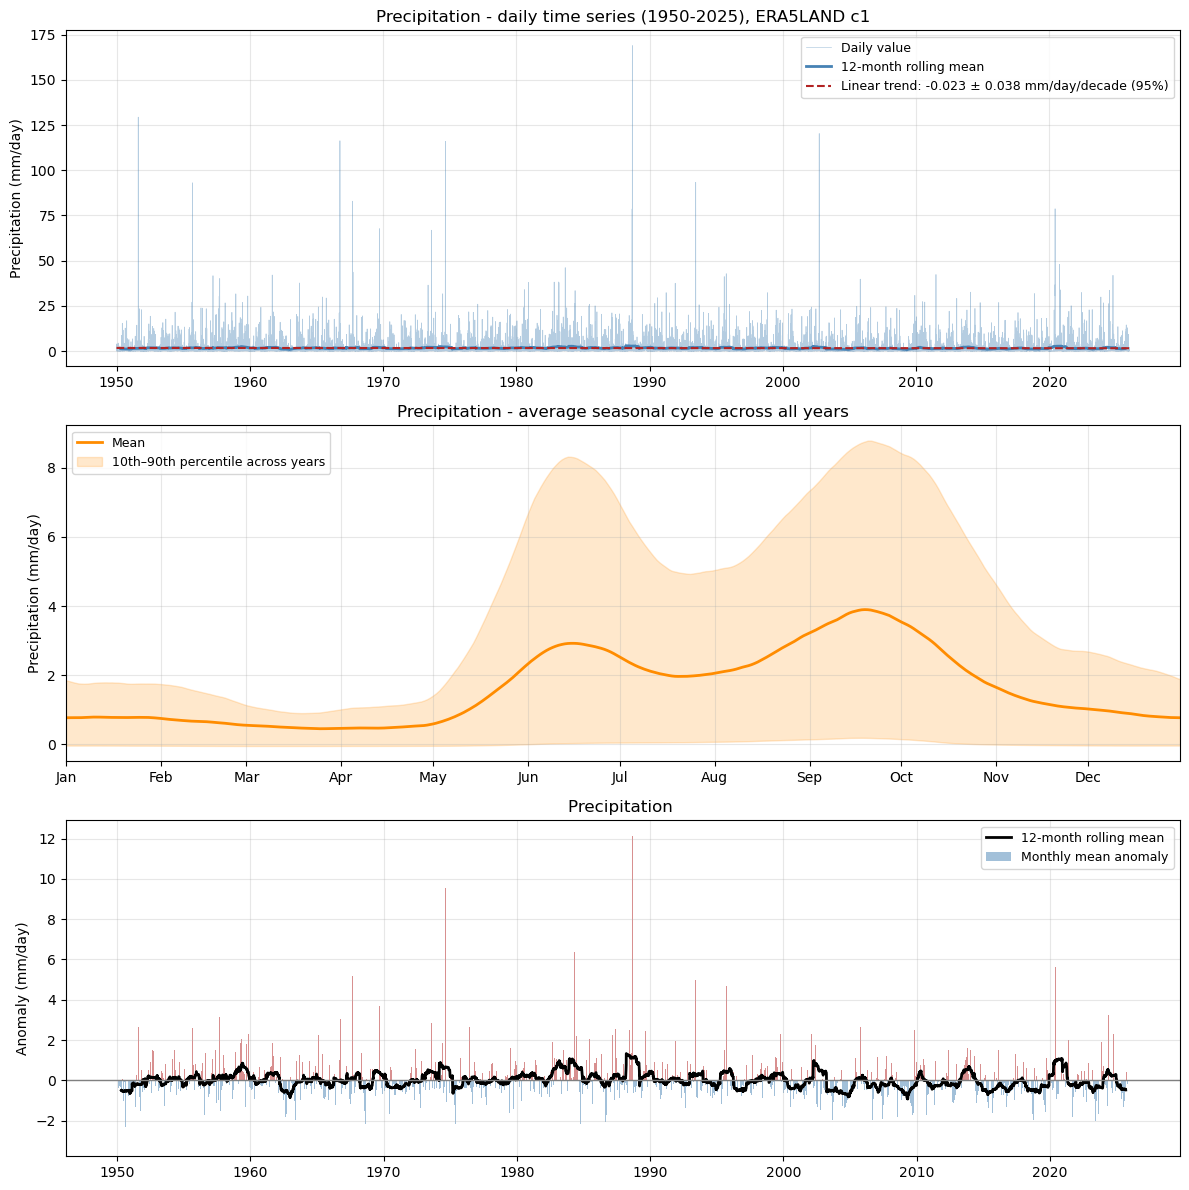

In [3]:
import matplotlib.pyplot as plt

anom = s - pd.Series(clim['mean'].reindex(doy).values, index=s.index)
anom_m = anom.resample('MS').mean()
roll_val = s.rolling(365, center=True, min_periods=300).mean()
roll_anom = anom.rolling(365, center=True, min_periods=300).mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
ax.plot(s.index, s.values, color='steelblue', alpha=0.4, lw=0.5, label='Daily value')
ax.plot(roll_val.index, roll_val.values, color='steelblue', lw=2, label='12-month rolling mean')
trend_lab = (f"Linear trend: {res.slope*10:+.3f} \u00b1 {res.stderr*10*1.96:.3f} {UNIT}/decade (95%)"
             if res is not None else f"Linear trend: {slope*10:+.3f} {UNIT}/decade")
ax.plot(s.index, slope * t_all + icpt, color='firebrick', linestyle='--', lw=1.5, label=trend_lab)
ax.set_title(f"{info['label']} - daily time series ({YEAR0}-{YEAR1}), {info['src'].upper()} {TAG}")
ax.set_ylabel(f"{info['label']} ({UNIT})")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
dd = clim.index.values
ax.plot(dd, clim['mean'], color='darkorange', lw=2, label='Mean')
ax.fill_between(dd, clim.p10, clim.p90, color='darkorange', alpha=0.2, label='10th\u201390th percentile across years')
starts = np.cumsum([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30]) + 1
ax.set_xticks(starts)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(1, 365)
ax.set_title(f"{info['label']} - average seasonal cycle across all years")
ax.set_ylabel(f"{info['label']} ({UNIT})")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom_m.values >= 0, 'firebrick', 'steelblue')
ax.bar(anom_m.index, anom_m.values, width=25, color=colors, alpha=0.5, label='Monthly mean anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2, label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.set_title(f"{info['label']} ")
ax.set_ylabel(f"Anomaly ({UNIT})")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

HYCOM bottom level(s) used: [np.float64(4.007843137254902), np.float64(6.488888888888888), np.float64(100.0)] m  <-- should be a single value
Bottom salinity [salinity_bottom_psu]: 1992-10-02 to 2024-09-05, 31.9 years, 2155 missing days
daily-fit trend: 0.069 PSU per decade
annual-fit trend: 0.074 ± 0.024 PSU per decade (95%)
Mann-Kendall: SignificanceResult(statistic=np.float64(0.4266666666666666), pvalue=np.float64(0.002397783422611727))
detrended before climatology: True
values per day-of-year window: ~286
             mean         p10         p90
count  365.000000  365.000000  365.000000
mean    36.426820   36.237179   36.575660
std      0.122909    0.227641    0.088825
min     36.164090   35.669597   36.456906
25%     36.377668   36.117775   36.498495
50%     36.409423   36.280439   36.543682
75%     36.532905   36.401737   36.669494
max     36.621290   36.517261   36.726471


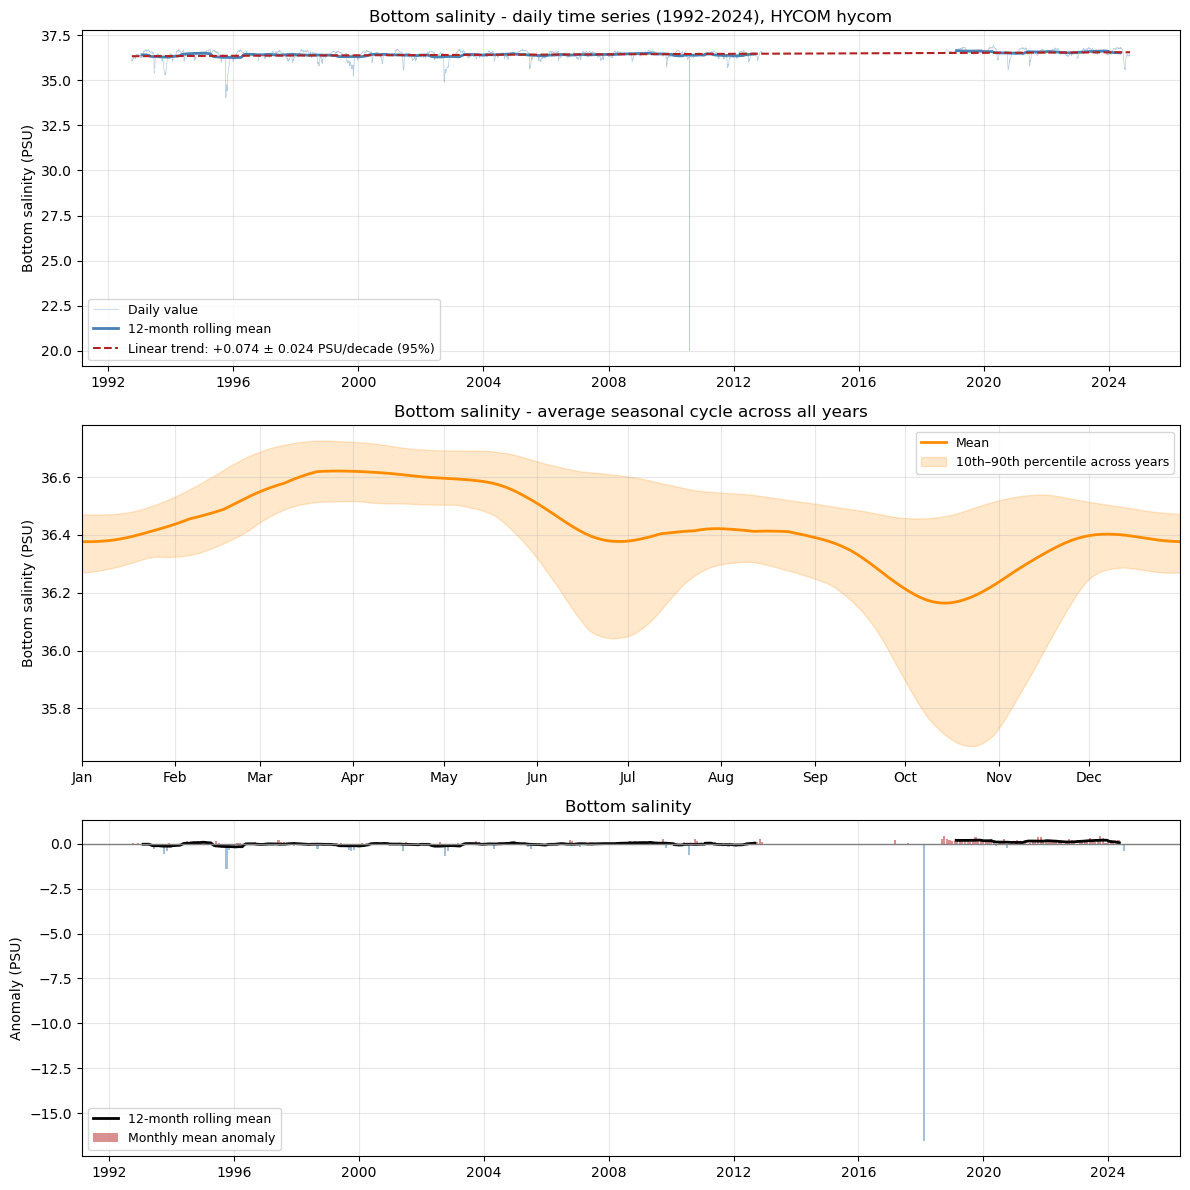

In [33]:
from scipy import stats

VAR  = 'salinity_bottom_psu'      # any key from VARIABLES except 'wave_dir_deg'
CELL = 'c1'         # ERA5-Land only: rerun with 'c2' to cross-check
WINDOW, SMOOTH = 11, 31    # days: percentile window and smoothing
DETREND = None             # None = automatic (only if >= 20 years of data)

s, info = load_series(VAR, CELL)
if info['kind'] == 'circular':
    raise ValueError('Directions cannot be detrended or put into percentiles. '
                     'Use Climatology_plots.ipynb for wave direction.')

TAG   = CELL if info['src'] == 'era5land' else info['src']
UNIT  = info['unit'] + ('/day' if info['kind'] == 'flux' else '')
valid = s.dropna()
YEAR0, YEAR1 = s.index[0].year, s.index[-1].year
N_YEARS = (s.index[-1] - s.index[0]).days / 365.25
if DETREND is None:
    DETREND = N_YEARS >= 20

# --- 1. linear trend on daily data -----------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
t     = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'daily-fit trend: {slope*10:.3f} {UNIT} per decade')

# --- 2. trend with uncertainty, on annual means (years >= 90% complete) ----
g   = s.resample('YE')
ann = g.mean()[g.count() >= 329]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:.3f} '
          f'± {res.stderr*10*1.96:.3f} {UNIT} per decade (95%)')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# --- 3. detrend (keeps the mean level) --------------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. day-of-year index, leap years collapsed onto a 365-day calendar ----
def doy365(idx):
    doy = idx.dayofyear.values.copy()
    doy[idx.is_leap_year & (doy > 59)] -= 1      # 29 Feb shares day 59
    return doy

doy = doy365(x.index)
r   = pd.Series(x.values, index=doy).dropna()

# --- 5. WINDOW-day climatology, wrapping at the year boundary --------------
half = WINDOW // 2
clim = {}
for d in range(1, 366):
    w = [(d + k - 1) % 365 + 1 for k in range(-half, half + 1)]
    v = r[r.index.isin(w)].values
    clim[d] = (v.mean(), np.percentile(v, 10), np.percentile(v, 90))
clim = pd.DataFrame(clim, index=['mean', 'p10', 'p90']).T
print(f'values per day-of-year window: ~{len(r) * WINDOW // 365}')

# --- 6. circular SMOOTH-day smoothing ----------------------------------------
clim = pd.concat([clim] * 3).rolling(SMOOTH, center=True).mean().iloc[365:730]
clim.index = range(1, 366)

print(clim.describe())
#clim.to_csv(f'climatology_{VAR}_{TAG}.csv', index_label='doy')

import matplotlib.pyplot as plt

anom = s - pd.Series(clim['mean'].reindex(doy).values, index=s.index)
anom_m = anom.resample('MS').mean()
roll_val = s.rolling(365, center=True, min_periods=300).mean()
roll_anom = anom.rolling(365, center=True, min_periods=300).mean()

fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
ax.plot(s.index, s.values, color='steelblue', alpha=0.4, lw=0.5, label='Daily value')
ax.plot(roll_val.index, roll_val.values, color='steelblue', lw=2, label='12-month rolling mean')
trend_lab = (f"Linear trend: {res.slope*10:+.3f} \u00b1 {res.stderr*10*1.96:.3f} {UNIT}/decade (95%)"
             if res is not None else f"Linear trend: {slope*10:+.3f} {UNIT}/decade")
ax.plot(s.index, slope * t_all + icpt, color='firebrick', linestyle='--', lw=1.5, label=trend_lab)
ax.set_title(f"{info['label']} - daily time series ({YEAR0}-{YEAR1}), {info['src'].upper()} {TAG}")
ax.set_ylabel(f"{info['label']} ({UNIT})")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
dd = clim.index.values
ax.plot(dd, clim['mean'], color='darkorange', lw=2, label='Mean')
ax.fill_between(dd, clim.p10, clim.p90, color='darkorange', alpha=0.2, label='10th\u201390th percentile across years')
starts = np.cumsum([0, 31, 28, 31, 30, 31, 30, 31, 31, 30, 31, 30]) + 1
ax.set_xticks(starts)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(1, 365)
ax.set_title(f"{info['label']} - average seasonal cycle across all years")
ax.set_ylabel(f"{info['label']} ({UNIT})")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom_m.values >= 0, 'firebrick', 'steelblue')
ax.bar(anom_m.index, anom_m.values, width=25, color=colors, alpha=0.5, label='Monthly mean anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2, label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.set_title(f"{info['label']} ")
ax.set_ylabel(f"Anomaly ({UNIT})")
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

traj 3: 30 points, using point_id 87


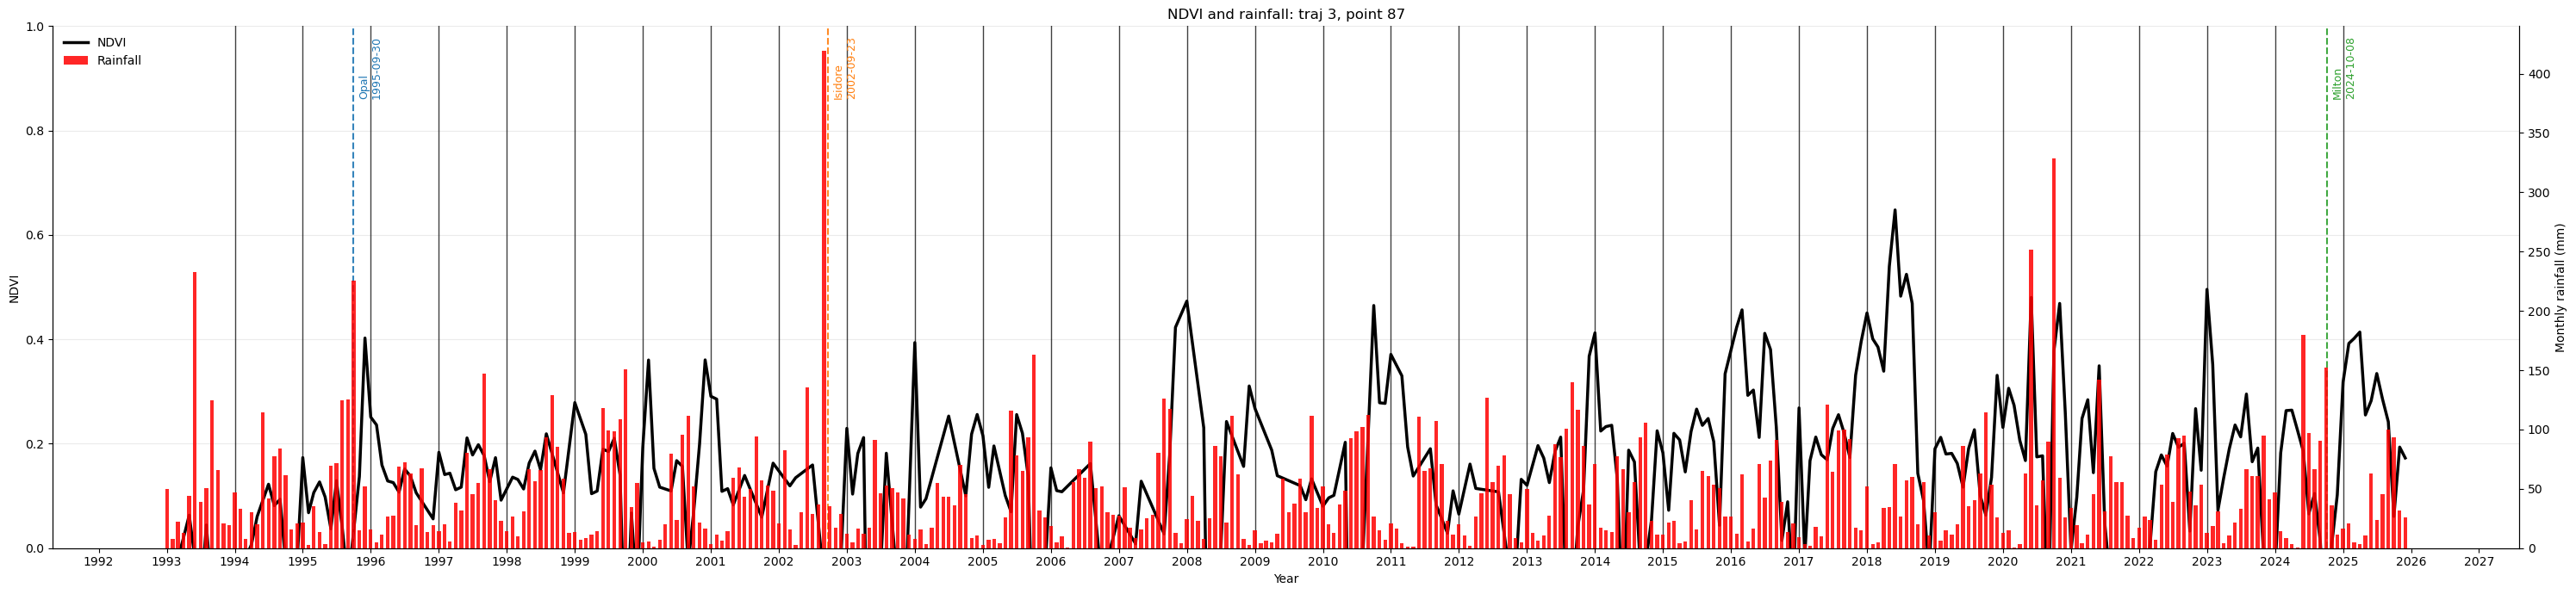

In [31]:
# NDVI and rainfall for one reproducibly selected trajectory-3 point
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
RAINFALL_PATH = Path('Sisal_ERA5Land_daily_all.csv')
TRAJ = 3
POINT_ID = None   # None = pick one point at random (reproducible); or set a specific id

STORMS = {
    'Opal': '1995-09-30',
    'Isidore': '2002-09-23',
    'Milton': '2024-10-08',
}

ndvi_df = pd.read_csv(NDVI_PATH)
traj_points = ndvi_df.loc[ndvi_df['traj'] == TRAJ, 'point_id'].drop_duplicates()
if traj_points.empty:
    raise ValueError(f'No points with traj == {TRAJ}. '
                     f'Available traj values: {sorted(ndvi_df["traj"].unique())}')

if POINT_ID is None:
    POINT_ID = int(traj_points.sample(1, random_state=42).iloc[0])
elif POINT_ID not in set(traj_points):
    raise ValueError(f'point_id {POINT_ID} is not in traj {TRAJ}. '
                     f'Example ids: {sorted(traj_points)[:10]}')
print(f'traj {TRAJ}: {len(traj_points)} points, using point_id {POINT_ID}')

ndvi = ndvi_df.loc[
    (ndvi_df['traj'] == TRAJ) & (ndvi_df['point_id'] == POINT_ID),
    ['year', 'month', 'ndvi_max']
].copy()
ndvi['date'] = pd.to_datetime(ndvi[['year', 'month']].assign(day=1))
ndvi = ndvi.set_index('date')['ndvi_max'].sort_index()

# Aggregate daily ERA5-Land precipitation to monthly rainfall totals.
rain_df = pd.read_csv(RAINFALL_PATH, parse_dates=['date'])
rain = (rain_df.set_index('date')['precip_mm_c1']
        .resample('MS').sum(min_count=1)
        .rename('rainfall_mm'))

start = max(ndvi.index.min(), rain.index.min())
end = min(ndvi.index.max(), rain.index.max())
ndvi = ndvi.loc[start:end]
rain = rain.loc[start:end]

fig, ax_ndvi = plt.subplots(figsize=(30, 7))
ax_rain = ax_ndvi.twinx()

ax_rain.bar(
    rain.index, rain.values,
    width=20, color='red', alpha=0.85, label='Rainfall'
)
ax_ndvi.plot(
    ndvi.index, ndvi.values,
    color='black', lw=2.5, label='NDVI'
)

# Black vertical lines mark calendar-year boundaries.
for year in range(start.year + 1, end.year + 1):
    year_start = pd.Timestamp(year=year, month=1, day=1)
    if year_start <= end:
        ax_ndvi.axvline(year_start, color='black', lw=1.0, alpha=0.75)

storm_colors = {'Opal': '#1f77b4', 'Isidore': '#ff7f0e', 'Milton': '#2ca02c'}
for name, date_text in STORMS.items():
    storm_date = pd.Timestamp(date_text)
    if start <= storm_date <= end:
        color = storm_colors[name]
        ax_ndvi.axvline(storm_date, color=color, lw=1.5, ls='--', alpha=0.9)
        ax_ndvi.annotate(
            f'{name}\n{storm_date:%Y-%m-%d}',
            xy=(storm_date, 0.98),
            xycoords=('data', 'axes fraction'),
            xytext=(4, 0),
            textcoords='offset points',
            rotation=90,
            va='top',
            ha='left',
            color=color,
            fontsize=9,
        )

ax_ndvi.set_title(f'NDVI and rainfall: traj {TRAJ}, point {POINT_ID}')
ax_ndvi.set_xlabel('Year')
ax_ndvi.set_ylabel('NDVI')
ax_rain.set_ylabel('Monthly rainfall (mm)')
ax_ndvi.set_ylim(0, 1)
ax_ndvi.xaxis.set_major_locator(mdates.YearLocator())
ax_ndvi.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax_ndvi.grid(axis='y', alpha=0.25)
ax_ndvi.spines['top'].set_visible(False)
ax_rain.spines['top'].set_visible(False)

handles_ndvi, labels_ndvi = ax_ndvi.get_legend_handles_labels()
handles_rain, labels_rain = ax_rain.get_legend_handles_labels()
ax_ndvi.legend(
    handles_ndvi + handles_rain,
    labels_ndvi + labels_rain,
    loc='upper left',
    frameon=False,
)
fig.tight_layout()
plt.show()


Opal: NDVI 44/49 months, rainfall 49/49 months
Isidore: NDVI 29/49 months, rainfall 49/49 months
Milton: NDVI 47/49 months, rainfall 39/49 months


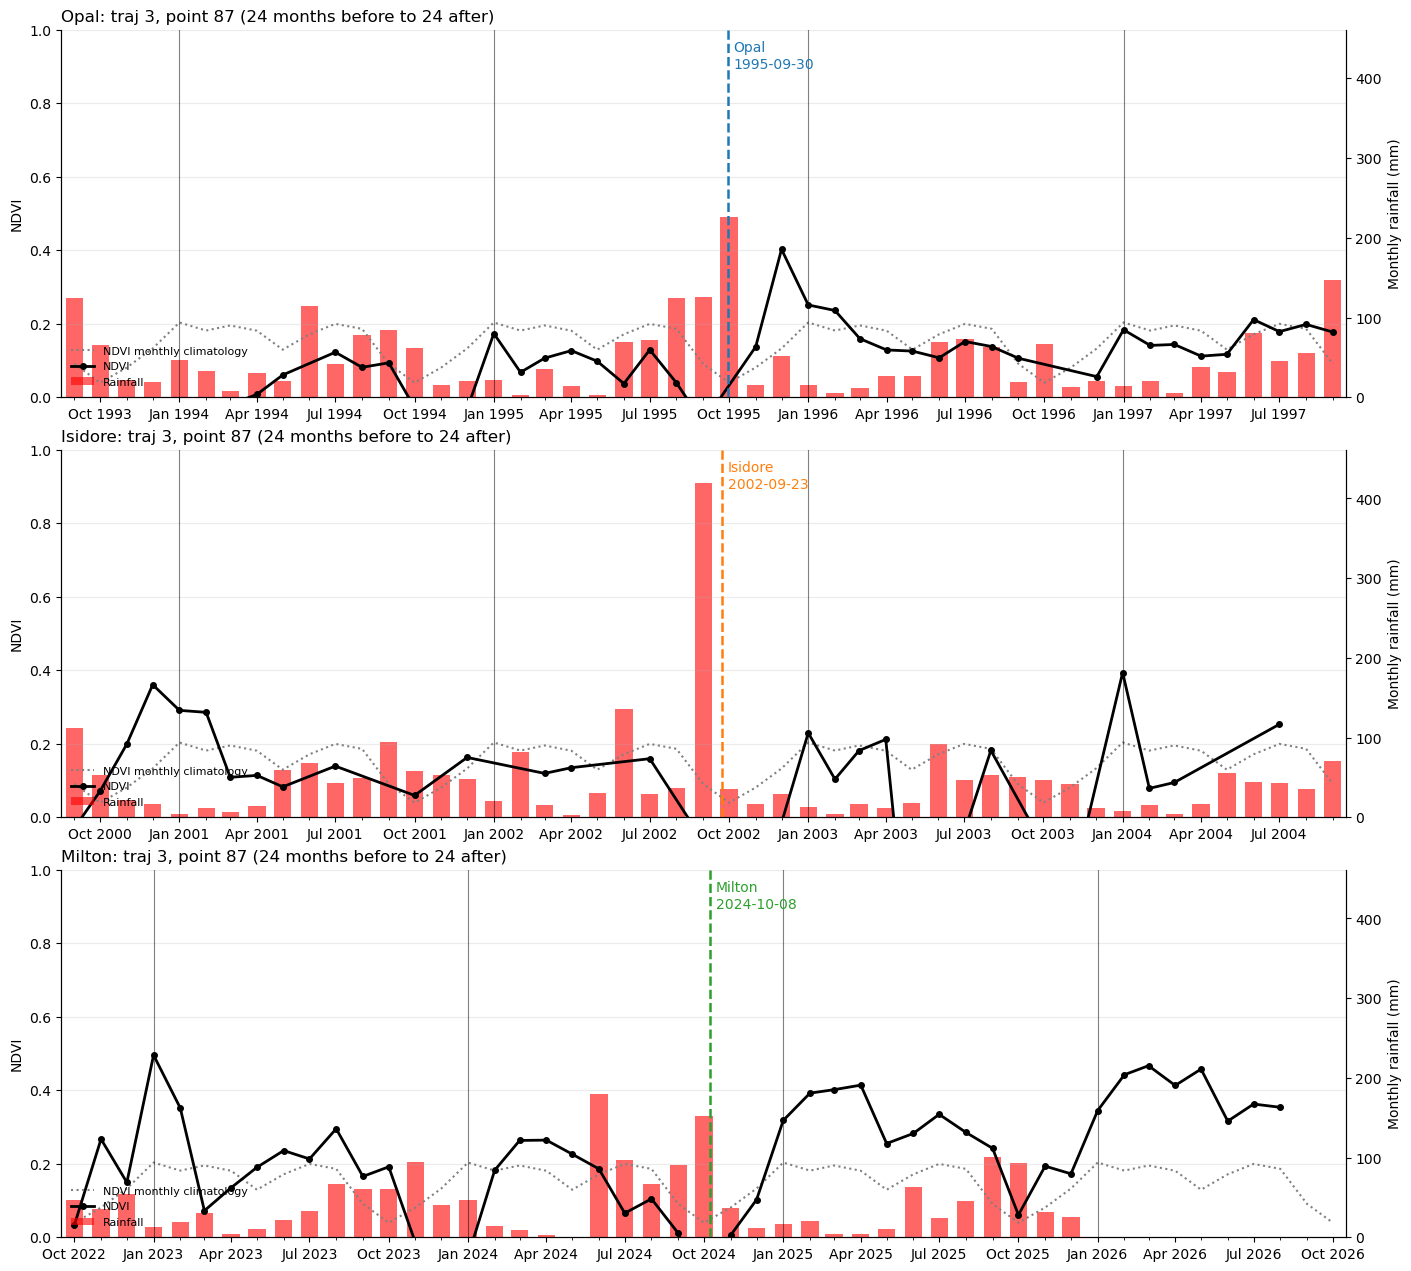

In [36]:
# Zoomed NDVI and rainfall panels: 1 year before and after Opal, Isidore and Milton
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

ZOOM_STORMS = [
    ('Opal', '1995-09-30', '#1f77b4'),
    ('Isidore', '2002-09-23', '#ff7f0e'),
    ('Milton', '2024-10-08', '#2ca02c'),
]
MONTHS_BEFORE = 24
MONTHS_AFTER = 24

# Reload full series (the overview cell clips ndvi/rain to their common period).
ndvi_full = ndvi_df.loc[
    (ndvi_df['traj'] == TRAJ) & (ndvi_df['point_id'] == POINT_ID),
    ['year', 'month', 'ndvi_max']
].copy()
ndvi_full['date'] = pd.to_datetime(ndvi_full[['year', 'month']].assign(day=1))
ndvi_full = ndvi_full.set_index('date')['ndvi_max'].sort_index()

rain_full = (rain_df.set_index('date')['precip_mm_c1']
             .resample('MS').sum(min_count=1)
             .rename('rainfall_mm'))

# Monthly NDVI climatology for this point (all years), as a seasonal reference.
ndvi_clim = ndvi_full.groupby(ndvi_full.index.month).mean()

fig, axes = plt.subplots(
    len(ZOOM_STORMS), 1,
    figsize=(14, 4.2 * len(ZOOM_STORMS)),
    constrained_layout=True,
)

# Calculate a shared rainfall y-limit so bar heights can be compared between panels.
rain_max = 0
for _, date_text, _ in ZOOM_STORMS:
    d = pd.Timestamp(date_text)
    w = rain_full.loc[d - pd.DateOffset(months=MONTHS_BEFORE):
                      d + pd.DateOffset(months=MONTHS_AFTER)]
    if w.notna().any():
        rain_max = max(rain_max, w.max())
rain_ylim = rain_max * 1.1 if rain_max > 0 else 1

for ax_ndvi, (name, date_text, color) in zip(axes, ZOOM_STORMS):
    storm_date = pd.Timestamp(date_text)
    win_start = (storm_date - pd.DateOffset(months=MONTHS_BEFORE)).replace(day=1)
    win_end = (storm_date + pd.DateOffset(months=MONTHS_AFTER)).replace(day=1)

    ndvi_win = ndvi_full.loc[win_start:win_end]
    rain_win = rain_full.loc[win_start:win_end]
    months = pd.date_range(win_start, win_end, freq='MS')
    clim_win = pd.Series(ndvi_clim.reindex(months.month).to_numpy(), index=months)

    ax_rain = ax_ndvi.twinx()
    ax_ndvi.set_zorder(ax_rain.get_zorder() + 1)   # NDVI line drawn above the bars
    ax_ndvi.patch.set_visible(False)

    ax_rain.bar(rain_win.index, rain_win.values, width=20,
                color='red', alpha=0.6, label='Rainfall')
    ax_ndvi.plot(clim_win.index, clim_win.values, color='gray', lw=1.5,
                 ls=':', label='NDVI monthly climatology')
    ax_ndvi.plot(ndvi_win.index, ndvi_win.values, color='black', lw=2.0,
                 marker='o', ms=4, label='NDVI')

    ax_ndvi.axvline(storm_date, color=color, lw=1.8, ls='--')
    ax_ndvi.annotate(f'{name}\n{storm_date:%Y-%m-%d}',
                     xy=(storm_date, 0.97), xycoords=('data', 'axes fraction'),
                     xytext=(4, 0), textcoords='offset points',
                     va='top', ha='left', color=color, fontsize=10)

    for year in range(win_start.year + 1, win_end.year + 1):
        ax_ndvi.axvline(pd.Timestamp(year=year, month=1, day=1),
                        color='black', lw=0.8, alpha=0.5)

    ax_ndvi.set_xlim(win_start - pd.Timedelta(days=15), win_end + pd.Timedelta(days=15))
    ax_ndvi.set_ylim(0, 1)
    ax_rain.set_ylim(0, rain_ylim)
    ax_ndvi.set_ylabel('NDVI')
    ax_rain.set_ylabel('Monthly rainfall (mm)')
    ax_ndvi.set_title(f'{name}: traj {TRAJ}, point {POINT_ID} '
                      f'({MONTHS_BEFORE} months before to {MONTHS_AFTER} after)',
                      loc='left')
    ax_ndvi.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax_ndvi.xaxis.set_minor_locator(mdates.MonthLocator())
    ax_ndvi.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_ndvi.grid(axis='y', alpha=0.25)
    ax_ndvi.spines['top'].set_visible(False)
    ax_rain.spines['top'].set_visible(False)

    h1, l1 = ax_ndvi.get_legend_handles_labels()
    h2, l2 = ax_rain.get_legend_handles_labels()
    ax_ndvi.legend(h1 + h2, l1 + l2, loc='lower left', frameon=False, fontsize=8)

    # Report data gaps so an empty panel isn't mistaken for a storm signal.
    n_months = len(months)
    print(f'{name}: NDVI {ndvi_win.notna().sum()}/{n_months} months, '
          f'rainfall {rain_win.notna().sum()}/{n_months} months')
    if rain_win.notna().sum() == 0:
        print(f'  WARNING: no rainfall data for {name} '
              f'(rainfall record ends {rain_full.dropna().index.max():%Y-%m-%d})')

plt.show()

NDVI, traj 1 (Stable interior), median of 30 points
months with data: 389 / 404
monthly-fit trend: +0.032 NDVI per decade
annual-fit trend: +0.032 ± 0.008 NDVI per decade (95%), n=34 years
Mann-Kendall: SignificanceResult(statistic=np.float64(0.572192513368984), pvalue=np.float64(1.9489560042622477e-06))
  before 2013: +0.006 NDVI/decade, mean 0.697 (n=20 years)
  from 2013: +0.016 NDVI/decade, mean 0.765 (n=14 years)
detrended before climatology: False
     mean    p10    p90  n_years
1   0.778  0.734  0.829       34
2   0.746  0.697  0.813       32
3   0.725  0.661  0.781       33
4   0.676  0.606  0.730       34
5   0.644  0.550  0.705       34
6   0.669  0.570  0.735       29
7   0.684  0.631  0.744       32
8   0.711  0.639  0.775       32
9   0.731  0.672  0.790       33
10  0.762  0.715  0.809       32
11  0.786  0.727  0.831       33
12  0.796  0.757  0.832       31


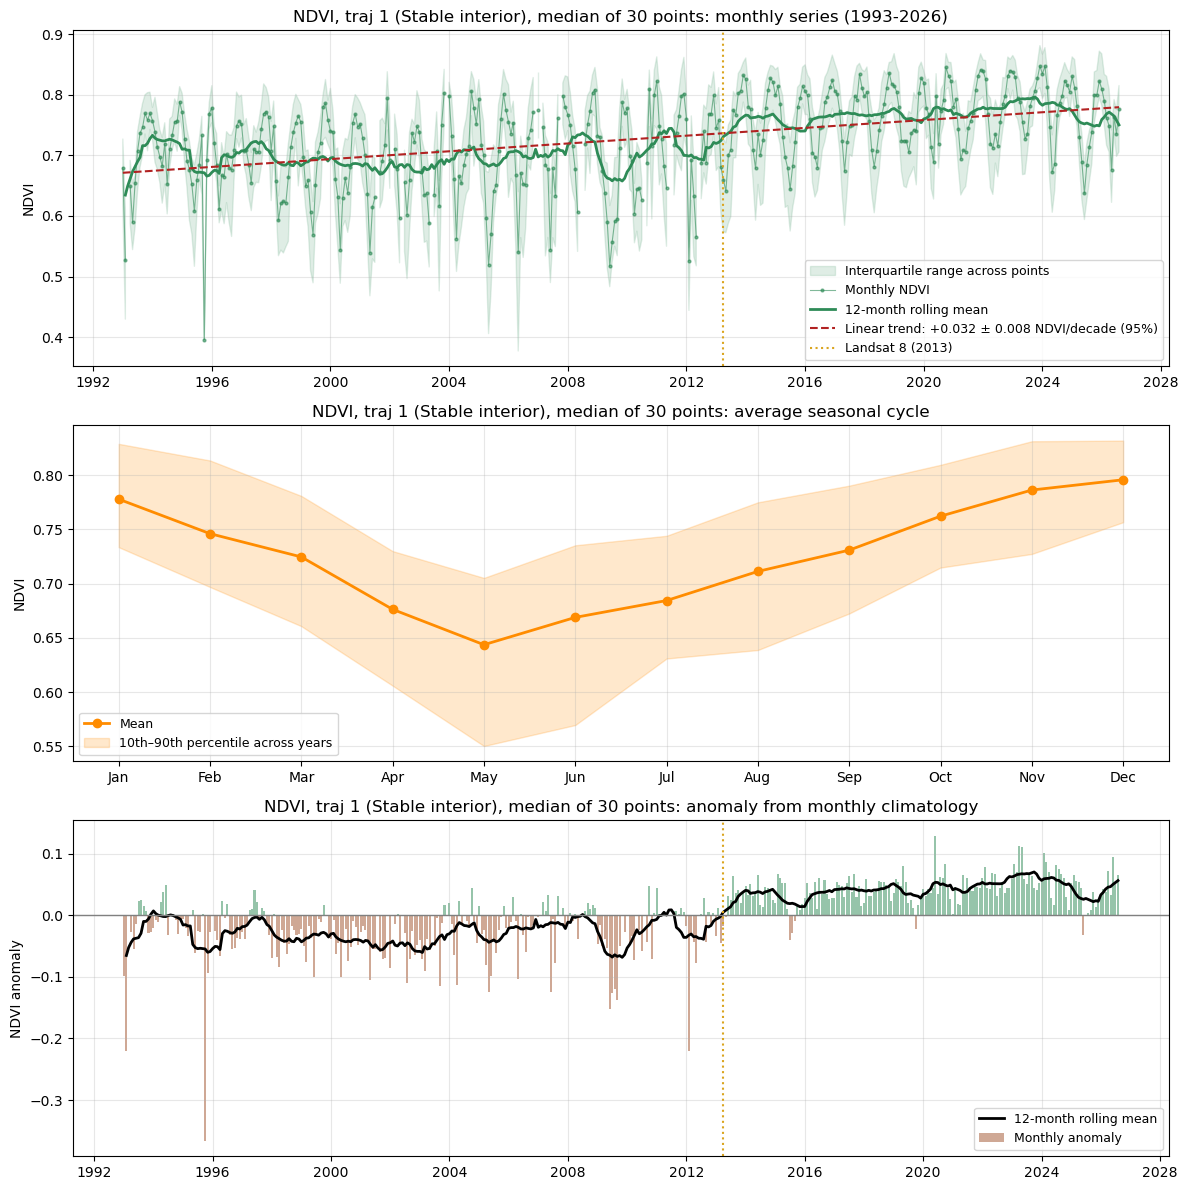

In [26]:
# NDVI: time series + trend, monthly seasonal cycle, and anomalies
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
TRAJ = 1
POINT_ID = None             # None = median of all points in TRAJ; or a point_id
DETREND = False             # trend is the signal for gain/loss classes, so off by default
MIN_MONTHS_PER_YEAR = 6     # annual means need at least this many months
SENSOR_BREAK = pd.Timestamp('2013-04-01')   # Landsat 8 operational

CLASS_NAMES = {1: 'Stable interior', 2: 'Stable edge', 3: 'Loss',
               4: 'Gain', 5: 'Loss then recovery'}

# --- 1. load and aggregate ---------------------------------------------------
ndvi_df = pd.read_csv(NDVI_PATH)
sub = ndvi_df[ndvi_df['traj'] == TRAJ].copy()
if POINT_ID is not None:
    sub = sub[sub['point_id'] == POINT_ID]
if sub.empty:
    raise ValueError(f'No data for traj={TRAJ}, point_id={POINT_ID}')
sub['date'] = pd.to_datetime(sub[['year', 'month']].assign(day=1))

wide = sub.pivot_table(index='date', columns='point_id', values='ndvi_max')
wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq='MS'))
s = wide.median(axis=1)                         # NaN where no point has data
q25, q75 = wide.quantile(0.25, axis=1), wide.quantile(0.75, axis=1)
n_points = wide.shape[1]

what = (f'point {POINT_ID}' if POINT_ID is not None
        else f'median of {n_points} points')
TITLE = f"NDVI, traj {TRAJ} ({CLASS_NAMES.get(TRAJ, '?')}), {what}"
YEAR0, YEAR1 = s.dropna().index[0].year, s.dropna().index[-1].year
print(TITLE)
print(f'months with data: {s.notna().sum()} / {len(s)}')

# --- 2. linear trend ---------------------------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
valid = s.dropna()
t = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'monthly-fit trend: {slope*10:+.3f} NDVI per decade')

g = s.resample('YE')
ann = g.mean()[g.count() >= MIN_MONTHS_PER_YEAR]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:+.3f} '
          f'± {res.stderr*10*1.96:.3f} NDVI per decade (95%), n={len(ann)} years')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# Trend before vs after Landsat 8: a jump between eras instead of a
# continuous slope points to a sensor/observation-count artifact.
for label, part in [('before 2013', ann[ann.index < SENSOR_BREAK]),
                    ('from 2013', ann[ann.index >= SENSOR_BREAK])]:
    if len(part) >= 3:
        r = stats.linregress(part.index.year, part.values)
        print(f'  {label}: {r.slope*10:+.3f} NDVI/decade, '
              f'mean {part.mean():.3f} (n={len(part)} years)')

# --- 3. optional detrend (keeps the mean level) ------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. monthly climatology ---------------------------------------------------
xv = x.dropna()
grp = xv.groupby(xv.index.month)
clim = pd.DataFrame({
    'mean': grp.mean(),
    'p10': grp.quantile(0.10),
    'p90': grp.quantile(0.90),
    'n_years': grp.count(),
}).reindex(range(1, 13))
print(clim.round(3))

# --- 5. anomalies and rolling means -------------------------------------------
anom = s - clim['mean'].reindex(s.index.month).to_numpy()
roll_val = s.rolling(12, center=True, min_periods=6).mean()
roll_anom = anom.rolling(12, center=True, min_periods=6).mean()

# --- 6. plot ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
if POINT_ID is None:
    ax.fill_between(s.index, q25, q75, color='seagreen', alpha=0.15,
                    label='Interquartile range across points')
ax.plot(s.index, s.values, color='seagreen', alpha=0.6, lw=0.8,
        marker='o', ms=2, label='Monthly NDVI')
ax.plot(roll_val.index, roll_val.values, color='seagreen', lw=2,
        label='12-month rolling mean')
trend_lab = (f'Linear trend: {res.slope*10:+.3f} ± {res.stderr*10*1.96:.3f} NDVI/decade (95%)'
             if res is not None else f'Linear trend: {slope*10:+.3f} NDVI/decade')
ax.plot(s.index, slope * t_all + icpt, color='firebrick', ls='--', lw=1.5, label=trend_lab)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':', label='Landsat 8 (2013)')
ax.set_title(f'{TITLE}: monthly series ({YEAR0}-{YEAR1})')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
mm = clim.index.values
ax.plot(mm, clim['mean'], color='darkorange', lw=2, marker='o', label='Mean')
ax.fill_between(mm, clim['p10'], clim['p90'], color='darkorange', alpha=0.2,
                label='10th–90th percentile across years')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(0.5, 12.5)
ax.set_title(f'{TITLE}: average seasonal cycle')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom.fillna(0).values >= 0, 'seagreen', 'sienna')
ax.bar(anom.index, anom.values, width=25, color=colors, alpha=0.5,
       label='Monthly anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2,
        label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':')
ax.set_title(f'{TITLE}: anomaly from monthly climatology')
ax.set_ylabel('NDVI anomaly')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

NDVI, traj 2 (Stable edge), median of 30 points
months with data: 390 / 404
monthly-fit trend: +0.045 NDVI per decade
annual-fit trend: +0.044 ± 0.008 NDVI per decade (95%), n=34 years
Mann-Kendall: SignificanceResult(statistic=np.float64(0.6934046345811052), pvalue=np.float64(8.083471122222437e-09))
  before 2013: +0.021 NDVI/decade, mean 0.665 (n=20 years)
  from 2013: +0.028 NDVI/decade, mean 0.753 (n=14 years)
detrended before climatology: False
     mean    p10    p90  n_years
1   0.756  0.675  0.822       34
2   0.718  0.634  0.799       32
3   0.686  0.614  0.764       33
4   0.640  0.568  0.709       34
5   0.614  0.506  0.691       34
6   0.647  0.564  0.730       29
7   0.673  0.625  0.736       32
8   0.699  0.623  0.763       32
9   0.716  0.637  0.790       33
10  0.738  0.683  0.807       33
11  0.767  0.703  0.817       33
12  0.765  0.709  0.829       31


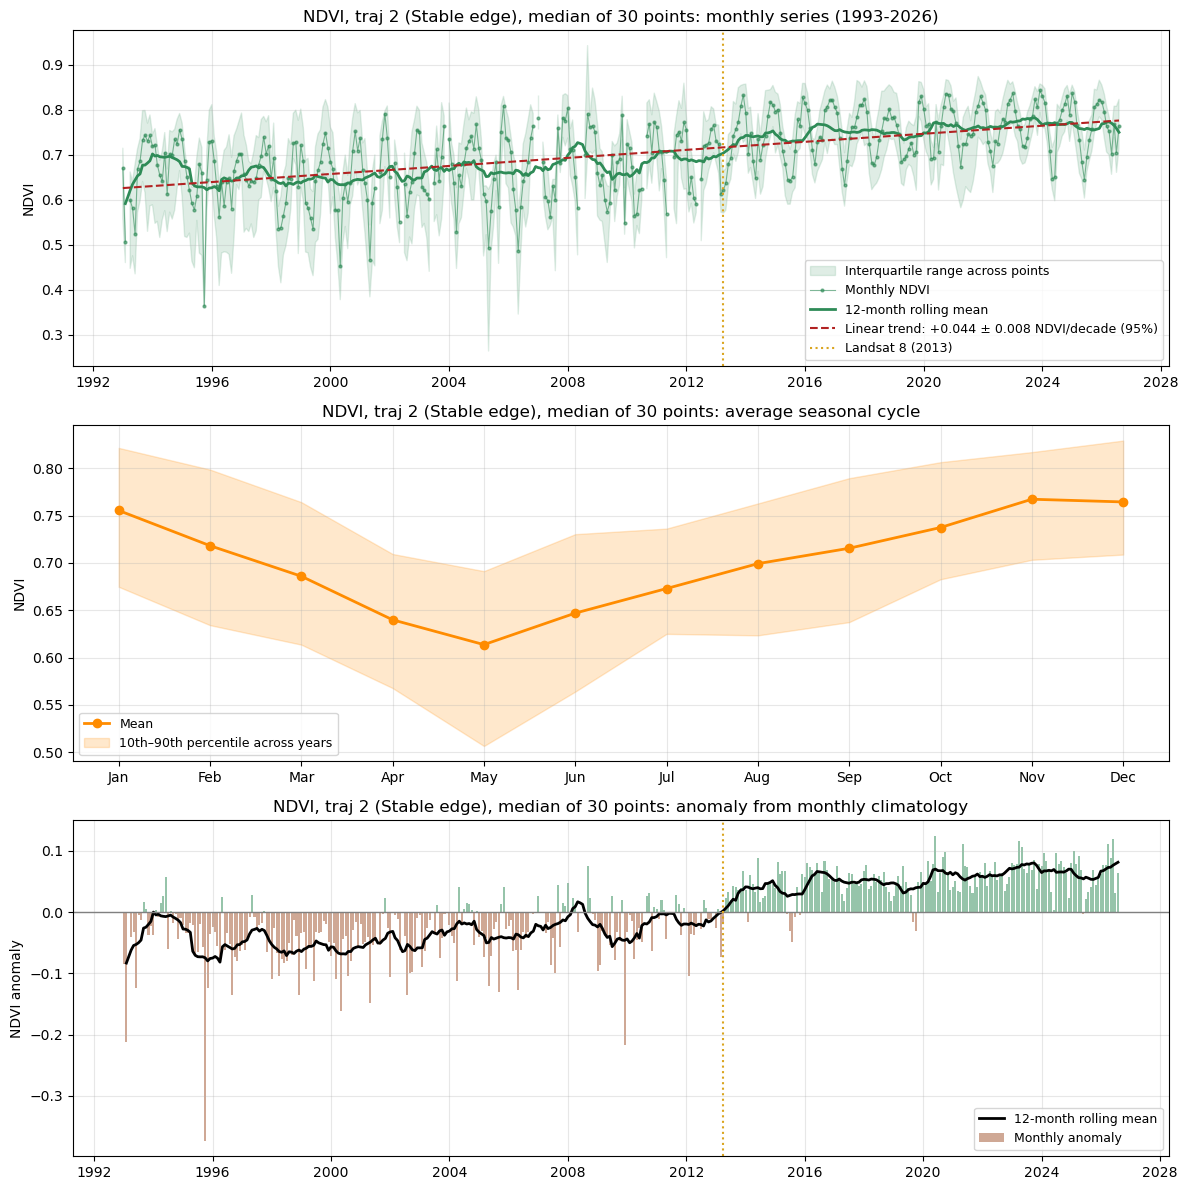

In [27]:
# NDVI: time series + trend, monthly seasonal cycle, and anomalies
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
TRAJ = 2
POINT_ID = None             # None = median of all points in TRAJ; or a point_id
DETREND = False             # trend is the signal for gain/loss classes, so off by default
MIN_MONTHS_PER_YEAR = 6     # annual means need at least this many months
SENSOR_BREAK = pd.Timestamp('2013-04-01')   # Landsat 8 operational

CLASS_NAMES = {1: 'Stable interior', 2: 'Stable edge', 3: 'Loss',
               4: 'Gain', 5: 'Loss then recovery'}

# --- 1. load and aggregate ---------------------------------------------------
ndvi_df = pd.read_csv(NDVI_PATH)
sub = ndvi_df[ndvi_df['traj'] == TRAJ].copy()
if POINT_ID is not None:
    sub = sub[sub['point_id'] == POINT_ID]
if sub.empty:
    raise ValueError(f'No data for traj={TRAJ}, point_id={POINT_ID}')
sub['date'] = pd.to_datetime(sub[['year', 'month']].assign(day=1))

wide = sub.pivot_table(index='date', columns='point_id', values='ndvi_max')
wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq='MS'))
s = wide.median(axis=1)                         # NaN where no point has data
q25, q75 = wide.quantile(0.25, axis=1), wide.quantile(0.75, axis=1)
n_points = wide.shape[1]

what = (f'point {POINT_ID}' if POINT_ID is not None
        else f'median of {n_points} points')
TITLE = f"NDVI, traj {TRAJ} ({CLASS_NAMES.get(TRAJ, '?')}), {what}"
YEAR0, YEAR1 = s.dropna().index[0].year, s.dropna().index[-1].year
print(TITLE)
print(f'months with data: {s.notna().sum()} / {len(s)}')

# --- 2. linear trend ---------------------------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
valid = s.dropna()
t = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'monthly-fit trend: {slope*10:+.3f} NDVI per decade')

g = s.resample('YE')
ann = g.mean()[g.count() >= MIN_MONTHS_PER_YEAR]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:+.3f} '
          f'± {res.stderr*10*1.96:.3f} NDVI per decade (95%), n={len(ann)} years')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# Trend before vs after Landsat 8: a jump between eras instead of a
# continuous slope points to a sensor/observation-count artifact.
for label, part in [('before 2013', ann[ann.index < SENSOR_BREAK]),
                    ('from 2013', ann[ann.index >= SENSOR_BREAK])]:
    if len(part) >= 3:
        r = stats.linregress(part.index.year, part.values)
        print(f'  {label}: {r.slope*10:+.3f} NDVI/decade, '
              f'mean {part.mean():.3f} (n={len(part)} years)')

# --- 3. optional detrend (keeps the mean level) ------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. monthly climatology ---------------------------------------------------
xv = x.dropna()
grp = xv.groupby(xv.index.month)
clim = pd.DataFrame({
    'mean': grp.mean(),
    'p10': grp.quantile(0.10),
    'p90': grp.quantile(0.90),
    'n_years': grp.count(),
}).reindex(range(1, 13))
print(clim.round(3))

# --- 5. anomalies and rolling means -------------------------------------------
anom = s - clim['mean'].reindex(s.index.month).to_numpy()
roll_val = s.rolling(12, center=True, min_periods=6).mean()
roll_anom = anom.rolling(12, center=True, min_periods=6).mean()

# --- 6. plot ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
if POINT_ID is None:
    ax.fill_between(s.index, q25, q75, color='seagreen', alpha=0.15,
                    label='Interquartile range across points')
ax.plot(s.index, s.values, color='seagreen', alpha=0.6, lw=0.8,
        marker='o', ms=2, label='Monthly NDVI')
ax.plot(roll_val.index, roll_val.values, color='seagreen', lw=2,
        label='12-month rolling mean')
trend_lab = (f'Linear trend: {res.slope*10:+.3f} ± {res.stderr*10*1.96:.3f} NDVI/decade (95%)'
             if res is not None else f'Linear trend: {slope*10:+.3f} NDVI/decade')
ax.plot(s.index, slope * t_all + icpt, color='firebrick', ls='--', lw=1.5, label=trend_lab)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':', label='Landsat 8 (2013)')
ax.set_title(f'{TITLE}: monthly series ({YEAR0}-{YEAR1})')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
mm = clim.index.values
ax.plot(mm, clim['mean'], color='darkorange', lw=2, marker='o', label='Mean')
ax.fill_between(mm, clim['p10'], clim['p90'], color='darkorange', alpha=0.2,
                label='10th–90th percentile across years')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(0.5, 12.5)
ax.set_title(f'{TITLE}: average seasonal cycle')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom.fillna(0).values >= 0, 'seagreen', 'sienna')
ax.bar(anom.index, anom.values, width=25, color=colors, alpha=0.5,
       label='Monthly anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2,
        label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':')
ax.set_title(f'{TITLE}: anomaly from monthly climatology')
ax.set_ylabel('NDVI anomaly')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

NDVI, traj 3 (Loss), median of 30 points
months with data: 390 / 404
monthly-fit trend: +0.038 NDVI per decade
annual-fit trend: +0.041 ± 0.031 NDVI per decade (95%), n=34 years
Mann-Kendall: SignificanceResult(statistic=np.float64(0.21568627450980396), pvalue=np.float64(0.07285186047170676))
  before 2013: -0.038 NDVI/decade, mean 0.132 (n=20 years)
  from 2013: +0.241 NDVI/decade, mean 0.205 (n=14 years)
detrended before climatology: False
     mean    p10    p90  n_years
1   0.194 -0.028  0.417       34
2   0.158  0.010  0.332       32
3   0.156  0.059  0.271       33
4   0.161  0.108  0.215       34
5   0.156  0.099  0.230       34
6   0.157  0.028  0.278       29
7   0.168  0.050  0.256       32
8   0.160  0.060  0.280       32
9   0.159 -0.013  0.291       33
10  0.120 -0.053  0.345       33
11  0.167 -0.053  0.439       33
12  0.187  0.026  0.398       31


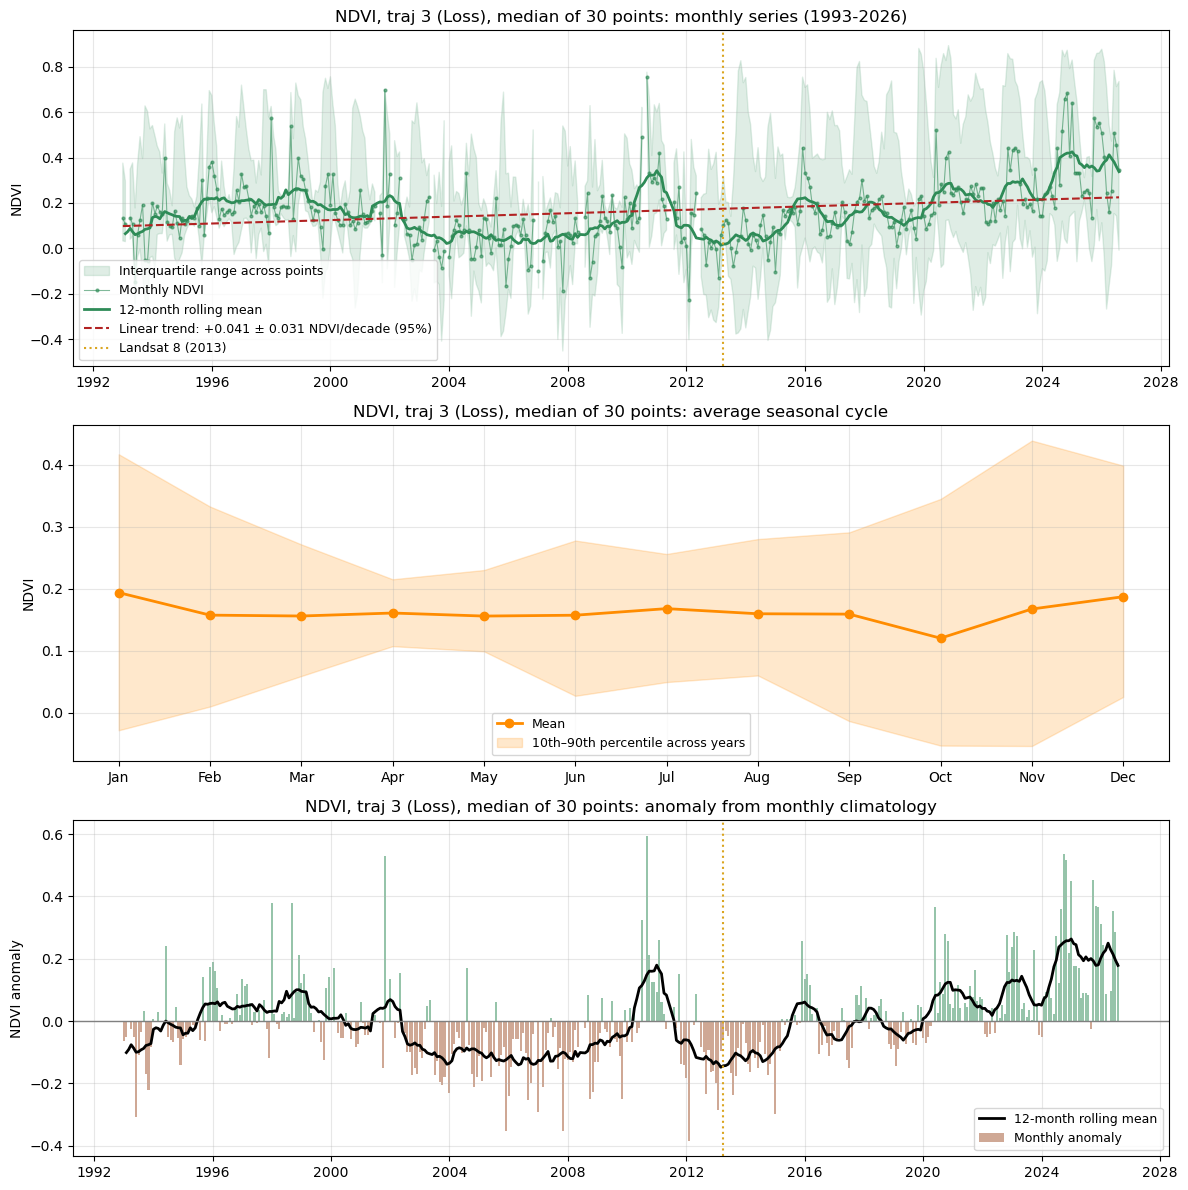

In [28]:
# NDVI: time series + trend, monthly seasonal cycle, and anomalies
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
TRAJ = 3
POINT_ID = None             # None = median of all points in TRAJ; or a point_id
DETREND = False             # trend is the signal for gain/loss classes, so off by default
MIN_MONTHS_PER_YEAR = 6     # annual means need at least this many months
SENSOR_BREAK = pd.Timestamp('2013-04-01')   # Landsat 8 operational

CLASS_NAMES = {1: 'Stable interior', 2: 'Stable edge', 3: 'Loss',
               4: 'Gain', 5: 'Loss then recovery'}

# --- 1. load and aggregate ---------------------------------------------------
ndvi_df = pd.read_csv(NDVI_PATH)
sub = ndvi_df[ndvi_df['traj'] == TRAJ].copy()
if POINT_ID is not None:
    sub = sub[sub['point_id'] == POINT_ID]
if sub.empty:
    raise ValueError(f'No data for traj={TRAJ}, point_id={POINT_ID}')
sub['date'] = pd.to_datetime(sub[['year', 'month']].assign(day=1))

wide = sub.pivot_table(index='date', columns='point_id', values='ndvi_max')
wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq='MS'))
s = wide.median(axis=1)                         # NaN where no point has data
q25, q75 = wide.quantile(0.25, axis=1), wide.quantile(0.75, axis=1)
n_points = wide.shape[1]

what = (f'point {POINT_ID}' if POINT_ID is not None
        else f'median of {n_points} points')
TITLE = f"NDVI, traj {TRAJ} ({CLASS_NAMES.get(TRAJ, '?')}), {what}"
YEAR0, YEAR1 = s.dropna().index[0].year, s.dropna().index[-1].year
print(TITLE)
print(f'months with data: {s.notna().sum()} / {len(s)}')

# --- 2. linear trend ---------------------------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
valid = s.dropna()
t = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'monthly-fit trend: {slope*10:+.3f} NDVI per decade')

g = s.resample('YE')
ann = g.mean()[g.count() >= MIN_MONTHS_PER_YEAR]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:+.3f} '
          f'± {res.stderr*10*1.96:.3f} NDVI per decade (95%), n={len(ann)} years')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# Trend before vs after Landsat 8: a jump between eras instead of a
# continuous slope points to a sensor/observation-count artifact.
for label, part in [('before 2013', ann[ann.index < SENSOR_BREAK]),
                    ('from 2013', ann[ann.index >= SENSOR_BREAK])]:
    if len(part) >= 3:
        r = stats.linregress(part.index.year, part.values)
        print(f'  {label}: {r.slope*10:+.3f} NDVI/decade, '
              f'mean {part.mean():.3f} (n={len(part)} years)')

# --- 3. optional detrend (keeps the mean level) ------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. monthly climatology ---------------------------------------------------
xv = x.dropna()
grp = xv.groupby(xv.index.month)
clim = pd.DataFrame({
    'mean': grp.mean(),
    'p10': grp.quantile(0.10),
    'p90': grp.quantile(0.90),
    'n_years': grp.count(),
}).reindex(range(1, 13))
print(clim.round(3))

# --- 5. anomalies and rolling means -------------------------------------------
anom = s - clim['mean'].reindex(s.index.month).to_numpy()
roll_val = s.rolling(12, center=True, min_periods=6).mean()
roll_anom = anom.rolling(12, center=True, min_periods=6).mean()

# --- 6. plot ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
if POINT_ID is None:
    ax.fill_between(s.index, q25, q75, color='seagreen', alpha=0.15,
                    label='Interquartile range across points')
ax.plot(s.index, s.values, color='seagreen', alpha=0.6, lw=0.8,
        marker='o', ms=2, label='Monthly NDVI')
ax.plot(roll_val.index, roll_val.values, color='seagreen', lw=2,
        label='12-month rolling mean')
trend_lab = (f'Linear trend: {res.slope*10:+.3f} ± {res.stderr*10*1.96:.3f} NDVI/decade (95%)'
             if res is not None else f'Linear trend: {slope*10:+.3f} NDVI/decade')
ax.plot(s.index, slope * t_all + icpt, color='firebrick', ls='--', lw=1.5, label=trend_lab)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':', label='Landsat 8 (2013)')
ax.set_title(f'{TITLE}: monthly series ({YEAR0}-{YEAR1})')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
mm = clim.index.values
ax.plot(mm, clim['mean'], color='darkorange', lw=2, marker='o', label='Mean')
ax.fill_between(mm, clim['p10'], clim['p90'], color='darkorange', alpha=0.2,
                label='10th–90th percentile across years')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(0.5, 12.5)
ax.set_title(f'{TITLE}: average seasonal cycle')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom.fillna(0).values >= 0, 'seagreen', 'sienna')
ax.bar(anom.index, anom.values, width=25, color=colors, alpha=0.5,
       label='Monthly anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2,
        label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':')
ax.set_title(f'{TITLE}: anomaly from monthly climatology')
ax.set_ylabel('NDVI anomaly')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

NDVI, traj 4 (Gain), median of 30 points
months with data: 387 / 404
monthly-fit trend: +0.260 NDVI per decade
annual-fit trend: +0.262 ± 0.038 NDVI per decade (95%), n=34 years
Mann-Kendall: SignificanceResult(statistic=np.float64(0.7754010695187167), pvalue=np.float64(1.1286360923915011e-10))
  before 2013: +0.103 NDVI/decade, mean 0.101 (n=20 years)
  from 2013: +0.357 NDVI/decade, mean 0.606 (n=14 years)
detrended before climatology: False
     mean    p10    p90  n_years
1   0.308  0.006  0.767       34
2   0.319 -0.060  0.760       32
3   0.321  0.052  0.729       33
4   0.315  0.081  0.657       34
5   0.317  0.100  0.640       34
6   0.363  0.099  0.684       29
7   0.327  0.076  0.690       30
8   0.345  0.108  0.714       32
9   0.276 -0.125  0.743       32
10  0.211 -0.233  0.779       33
11  0.307 -0.130  0.788       33
12  0.357 -0.119  0.779       31


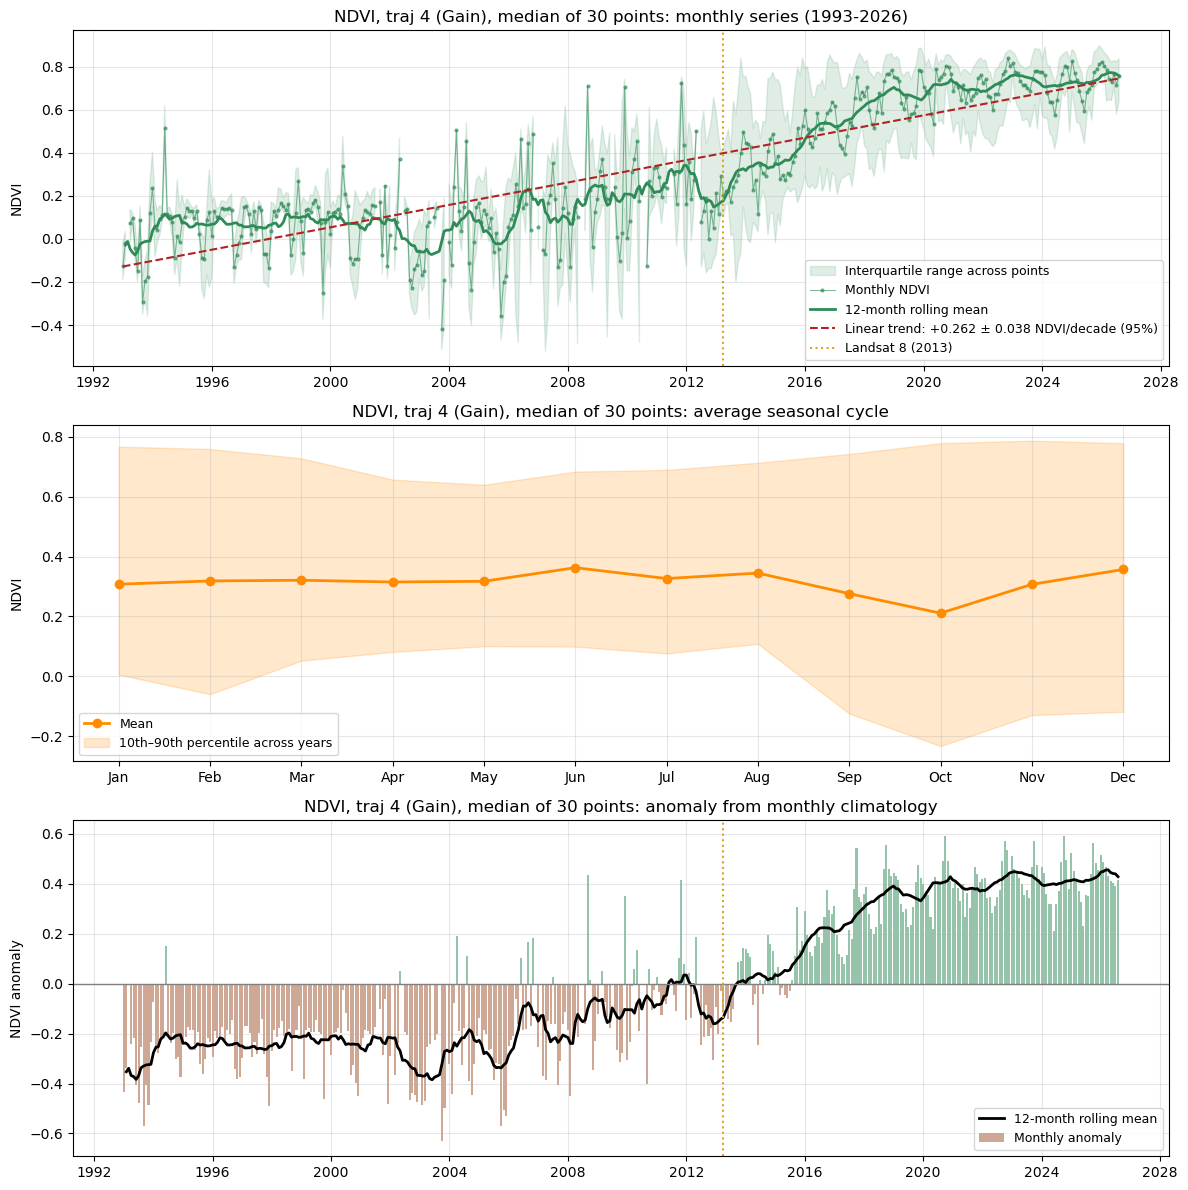

In [29]:
# NDVI: time series + trend, monthly seasonal cycle, and anomalies
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
TRAJ = 4
POINT_ID = None             # None = median of all points in TRAJ; or a point_id
DETREND = False             # trend is the signal for gain/loss classes, so off by default
MIN_MONTHS_PER_YEAR = 6     # annual means need at least this many months
SENSOR_BREAK = pd.Timestamp('2013-04-01')   # Landsat 8 operational

CLASS_NAMES = {1: 'Stable interior', 2: 'Stable edge', 3: 'Loss',
               4: 'Gain', 5: 'Loss then recovery'}

# --- 1. load and aggregate ---------------------------------------------------
ndvi_df = pd.read_csv(NDVI_PATH)
sub = ndvi_df[ndvi_df['traj'] == TRAJ].copy()
if POINT_ID is not None:
    sub = sub[sub['point_id'] == POINT_ID]
if sub.empty:
    raise ValueError(f'No data for traj={TRAJ}, point_id={POINT_ID}')
sub['date'] = pd.to_datetime(sub[['year', 'month']].assign(day=1))

wide = sub.pivot_table(index='date', columns='point_id', values='ndvi_max')
wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq='MS'))
s = wide.median(axis=1)                         # NaN where no point has data
q25, q75 = wide.quantile(0.25, axis=1), wide.quantile(0.75, axis=1)
n_points = wide.shape[1]

what = (f'point {POINT_ID}' if POINT_ID is not None
        else f'median of {n_points} points')
TITLE = f"NDVI, traj {TRAJ} ({CLASS_NAMES.get(TRAJ, '?')}), {what}"
YEAR0, YEAR1 = s.dropna().index[0].year, s.dropna().index[-1].year
print(TITLE)
print(f'months with data: {s.notna().sum()} / {len(s)}')

# --- 2. linear trend ---------------------------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
valid = s.dropna()
t = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'monthly-fit trend: {slope*10:+.3f} NDVI per decade')

g = s.resample('YE')
ann = g.mean()[g.count() >= MIN_MONTHS_PER_YEAR]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:+.3f} '
          f'± {res.stderr*10*1.96:.3f} NDVI per decade (95%), n={len(ann)} years')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# Trend before vs after Landsat 8: a jump between eras instead of a
# continuous slope points to a sensor/observation-count artifact.
for label, part in [('before 2013', ann[ann.index < SENSOR_BREAK]),
                    ('from 2013', ann[ann.index >= SENSOR_BREAK])]:
    if len(part) >= 3:
        r = stats.linregress(part.index.year, part.values)
        print(f'  {label}: {r.slope*10:+.3f} NDVI/decade, '
              f'mean {part.mean():.3f} (n={len(part)} years)')

# --- 3. optional detrend (keeps the mean level) ------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. monthly climatology ---------------------------------------------------
xv = x.dropna()
grp = xv.groupby(xv.index.month)
clim = pd.DataFrame({
    'mean': grp.mean(),
    'p10': grp.quantile(0.10),
    'p90': grp.quantile(0.90),
    'n_years': grp.count(),
}).reindex(range(1, 13))
print(clim.round(3))

# --- 5. anomalies and rolling means -------------------------------------------
anom = s - clim['mean'].reindex(s.index.month).to_numpy()
roll_val = s.rolling(12, center=True, min_periods=6).mean()
roll_anom = anom.rolling(12, center=True, min_periods=6).mean()

# --- 6. plot ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
if POINT_ID is None:
    ax.fill_between(s.index, q25, q75, color='seagreen', alpha=0.15,
                    label='Interquartile range across points')
ax.plot(s.index, s.values, color='seagreen', alpha=0.6, lw=0.8,
        marker='o', ms=2, label='Monthly NDVI')
ax.plot(roll_val.index, roll_val.values, color='seagreen', lw=2,
        label='12-month rolling mean')
trend_lab = (f'Linear trend: {res.slope*10:+.3f} ± {res.stderr*10*1.96:.3f} NDVI/decade (95%)'
             if res is not None else f'Linear trend: {slope*10:+.3f} NDVI/decade')
ax.plot(s.index, slope * t_all + icpt, color='firebrick', ls='--', lw=1.5, label=trend_lab)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':', label='Landsat 8 (2013)')
ax.set_title(f'{TITLE}: monthly series ({YEAR0}-{YEAR1})')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
mm = clim.index.values
ax.plot(mm, clim['mean'], color='darkorange', lw=2, marker='o', label='Mean')
ax.fill_between(mm, clim['p10'], clim['p90'], color='darkorange', alpha=0.2,
                label='10th–90th percentile across years')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(0.5, 12.5)
ax.set_title(f'{TITLE}: average seasonal cycle')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom.fillna(0).values >= 0, 'seagreen', 'sienna')
ax.bar(anom.index, anom.values, width=25, color=colors, alpha=0.5,
       label='Monthly anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2,
        label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':')
ax.set_title(f'{TITLE}: anomaly from monthly climatology')
ax.set_ylabel('NDVI anomaly')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

NDVI, traj 5 (Loss then recovery), median of 30 points
months with data: 390 / 404
monthly-fit trend: +0.173 NDVI per decade
annual-fit trend: +0.174 ± 0.030 NDVI per decade (95%), n=34 years
Mann-Kendall: SignificanceResult(statistic=np.float64(0.6684491978609627), pvalue=np.float64(2.7106641047386475e-08))
  before 2013: +0.040 NDVI/decade, mean 0.185 (n=20 years)
  from 2013: +0.303 NDVI/decade, mean 0.524 (n=14 years)
detrended before climatology: False
     mean    p10    p90  n_years
1   0.387  0.154  0.727       34
2   0.352  0.102  0.696       32
3   0.314  0.127  0.649       33
4   0.272  0.112  0.570       34
5   0.242  0.124  0.514       34
6   0.266  0.102  0.544       29
7   0.276  0.111  0.584       32
8   0.298  0.122  0.562       32
9   0.305  0.118  0.603       33
10  0.343  0.052  0.730       33
11  0.425  0.185  0.781       33
12  0.424  0.098  0.731       31


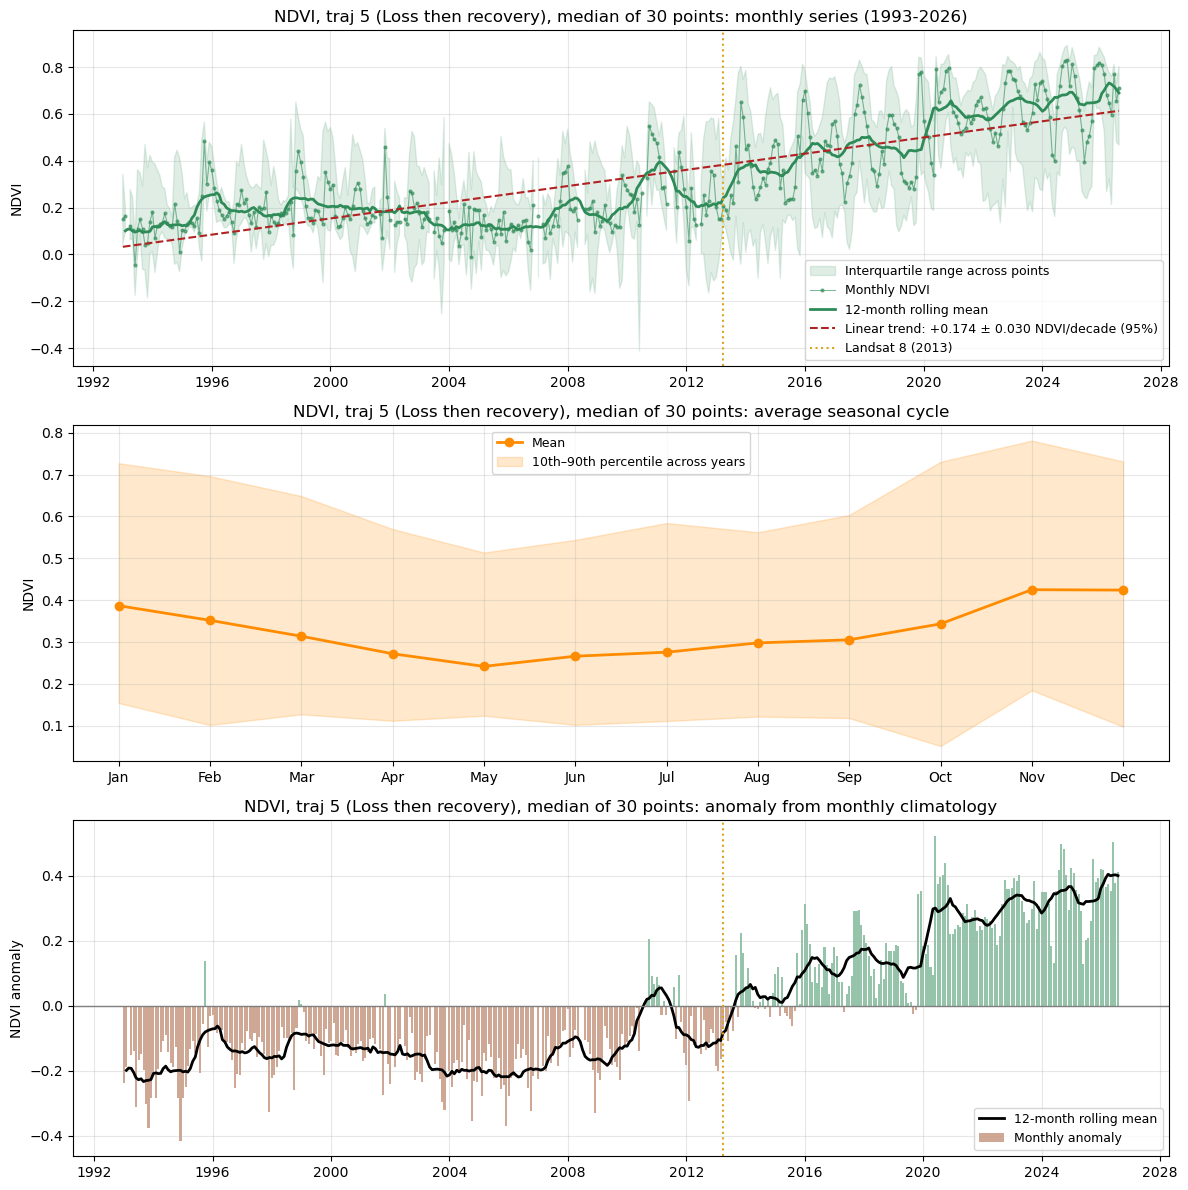

In [30]:
# NDVI: time series + trend, monthly seasonal cycle, and anomalies
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
TRAJ = 5
POINT_ID = None             # None = median of all points in TRAJ; or a point_id
DETREND = False             # trend is the signal for gain/loss classes, so off by default
MIN_MONTHS_PER_YEAR = 6     # annual means need at least this many months
SENSOR_BREAK = pd.Timestamp('2013-04-01')   # Landsat 8 operational

CLASS_NAMES = {1: 'Stable interior', 2: 'Stable edge', 3: 'Loss',
               4: 'Gain', 5: 'Loss then recovery'}

# --- 1. load and aggregate ---------------------------------------------------
ndvi_df = pd.read_csv(NDVI_PATH)
sub = ndvi_df[ndvi_df['traj'] == TRAJ].copy()
if POINT_ID is not None:
    sub = sub[sub['point_id'] == POINT_ID]
if sub.empty:
    raise ValueError(f'No data for traj={TRAJ}, point_id={POINT_ID}')
sub['date'] = pd.to_datetime(sub[['year', 'month']].assign(day=1))

wide = sub.pivot_table(index='date', columns='point_id', values='ndvi_max')
wide = wide.reindex(pd.date_range(wide.index.min(), wide.index.max(), freq='MS'))
s = wide.median(axis=1)                         # NaN where no point has data
q25, q75 = wide.quantile(0.25, axis=1), wide.quantile(0.75, axis=1)
n_points = wide.shape[1]

what = (f'point {POINT_ID}' if POINT_ID is not None
        else f'median of {n_points} points')
TITLE = f"NDVI, traj {TRAJ} ({CLASS_NAMES.get(TRAJ, '?')}), {what}"
YEAR0, YEAR1 = s.dropna().index[0].year, s.dropna().index[-1].year
print(TITLE)
print(f'months with data: {s.notna().sum()} / {len(s)}')

# --- 2. linear trend ---------------------------------------------------------
t_all = (s.index - s.index[0]).days.values / 365.25
valid = s.dropna()
t = t_all[s.notna().values]
slope, icpt = np.polyfit(t, valid.values, 1)
print(f'monthly-fit trend: {slope*10:+.3f} NDVI per decade')

g = s.resample('YE')
ann = g.mean()[g.count() >= MIN_MONTHS_PER_YEAR]
if len(ann) >= 3:
    res = stats.linregress(ann.index.year, ann.values)
    print(f'annual-fit trend: {res.slope*10:+.3f} '
          f'± {res.stderr*10*1.96:.3f} NDVI per decade (95%), n={len(ann)} years')
    print('Mann-Kendall:', stats.kendalltau(ann.index.year, ann.values))
else:
    res = None
    print('Too few complete years for an annual trend.')

# Trend before vs after Landsat 8: a jump between eras instead of a
# continuous slope points to a sensor/observation-count artifact.
for label, part in [('before 2013', ann[ann.index < SENSOR_BREAK]),
                    ('from 2013', ann[ann.index >= SENSOR_BREAK])]:
    if len(part) >= 3:
        r = stats.linregress(part.index.year, part.values)
        print(f'  {label}: {r.slope*10:+.3f} NDVI/decade, '
              f'mean {part.mean():.3f} (n={len(part)} years)')

# --- 3. optional detrend (keeps the mean level) ------------------------------
x = s - slope * (t_all - t.mean()) if DETREND else s.copy()
print('detrended before climatology:', DETREND)

# --- 4. monthly climatology ---------------------------------------------------
xv = x.dropna()
grp = xv.groupby(xv.index.month)
clim = pd.DataFrame({
    'mean': grp.mean(),
    'p10': grp.quantile(0.10),
    'p90': grp.quantile(0.90),
    'n_years': grp.count(),
}).reindex(range(1, 13))
print(clim.round(3))

# --- 5. anomalies and rolling means -------------------------------------------
anom = s - clim['mean'].reindex(s.index.month).to_numpy()
roll_val = s.rolling(12, center=True, min_periods=6).mean()
roll_anom = anom.rolling(12, center=True, min_periods=6).mean()

# --- 6. plot ------------------------------------------------------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

ax = axes[0]
if POINT_ID is None:
    ax.fill_between(s.index, q25, q75, color='seagreen', alpha=0.15,
                    label='Interquartile range across points')
ax.plot(s.index, s.values, color='seagreen', alpha=0.6, lw=0.8,
        marker='o', ms=2, label='Monthly NDVI')
ax.plot(roll_val.index, roll_val.values, color='seagreen', lw=2,
        label='12-month rolling mean')
trend_lab = (f'Linear trend: {res.slope*10:+.3f} ± {res.stderr*10*1.96:.3f} NDVI/decade (95%)'
             if res is not None else f'Linear trend: {slope*10:+.3f} NDVI/decade')
ax.plot(s.index, slope * t_all + icpt, color='firebrick', ls='--', lw=1.5, label=trend_lab)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':', label='Landsat 8 (2013)')
ax.set_title(f'{TITLE}: monthly series ({YEAR0}-{YEAR1})')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
mm = clim.index.values
ax.plot(mm, clim['mean'], color='darkorange', lw=2, marker='o', label='Mean')
ax.fill_between(mm, clim['p10'], clim['p90'], color='darkorange', alpha=0.2,
                label='10th–90th percentile across years')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.set_xlim(0.5, 12.5)
ax.set_title(f'{TITLE}: average seasonal cycle')
ax.set_ylabel('NDVI')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

ax = axes[2]
colors = np.where(anom.fillna(0).values >= 0, 'seagreen', 'sienna')
ax.bar(anom.index, anom.values, width=25, color=colors, alpha=0.5,
       label='Monthly anomaly')
ax.plot(roll_anom.index, roll_anom.values, color='black', lw=2,
        label='12-month rolling mean')
ax.axhline(0, color='grey', lw=1)
ax.axvline(SENSOR_BREAK, color='goldenrod', lw=1.5, ls=':')
ax.set_title(f'{TITLE}: anomaly from monthly climatology')
ax.set_ylabel('NDVI anomaly')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)

fig.tight_layout()
plt.show()

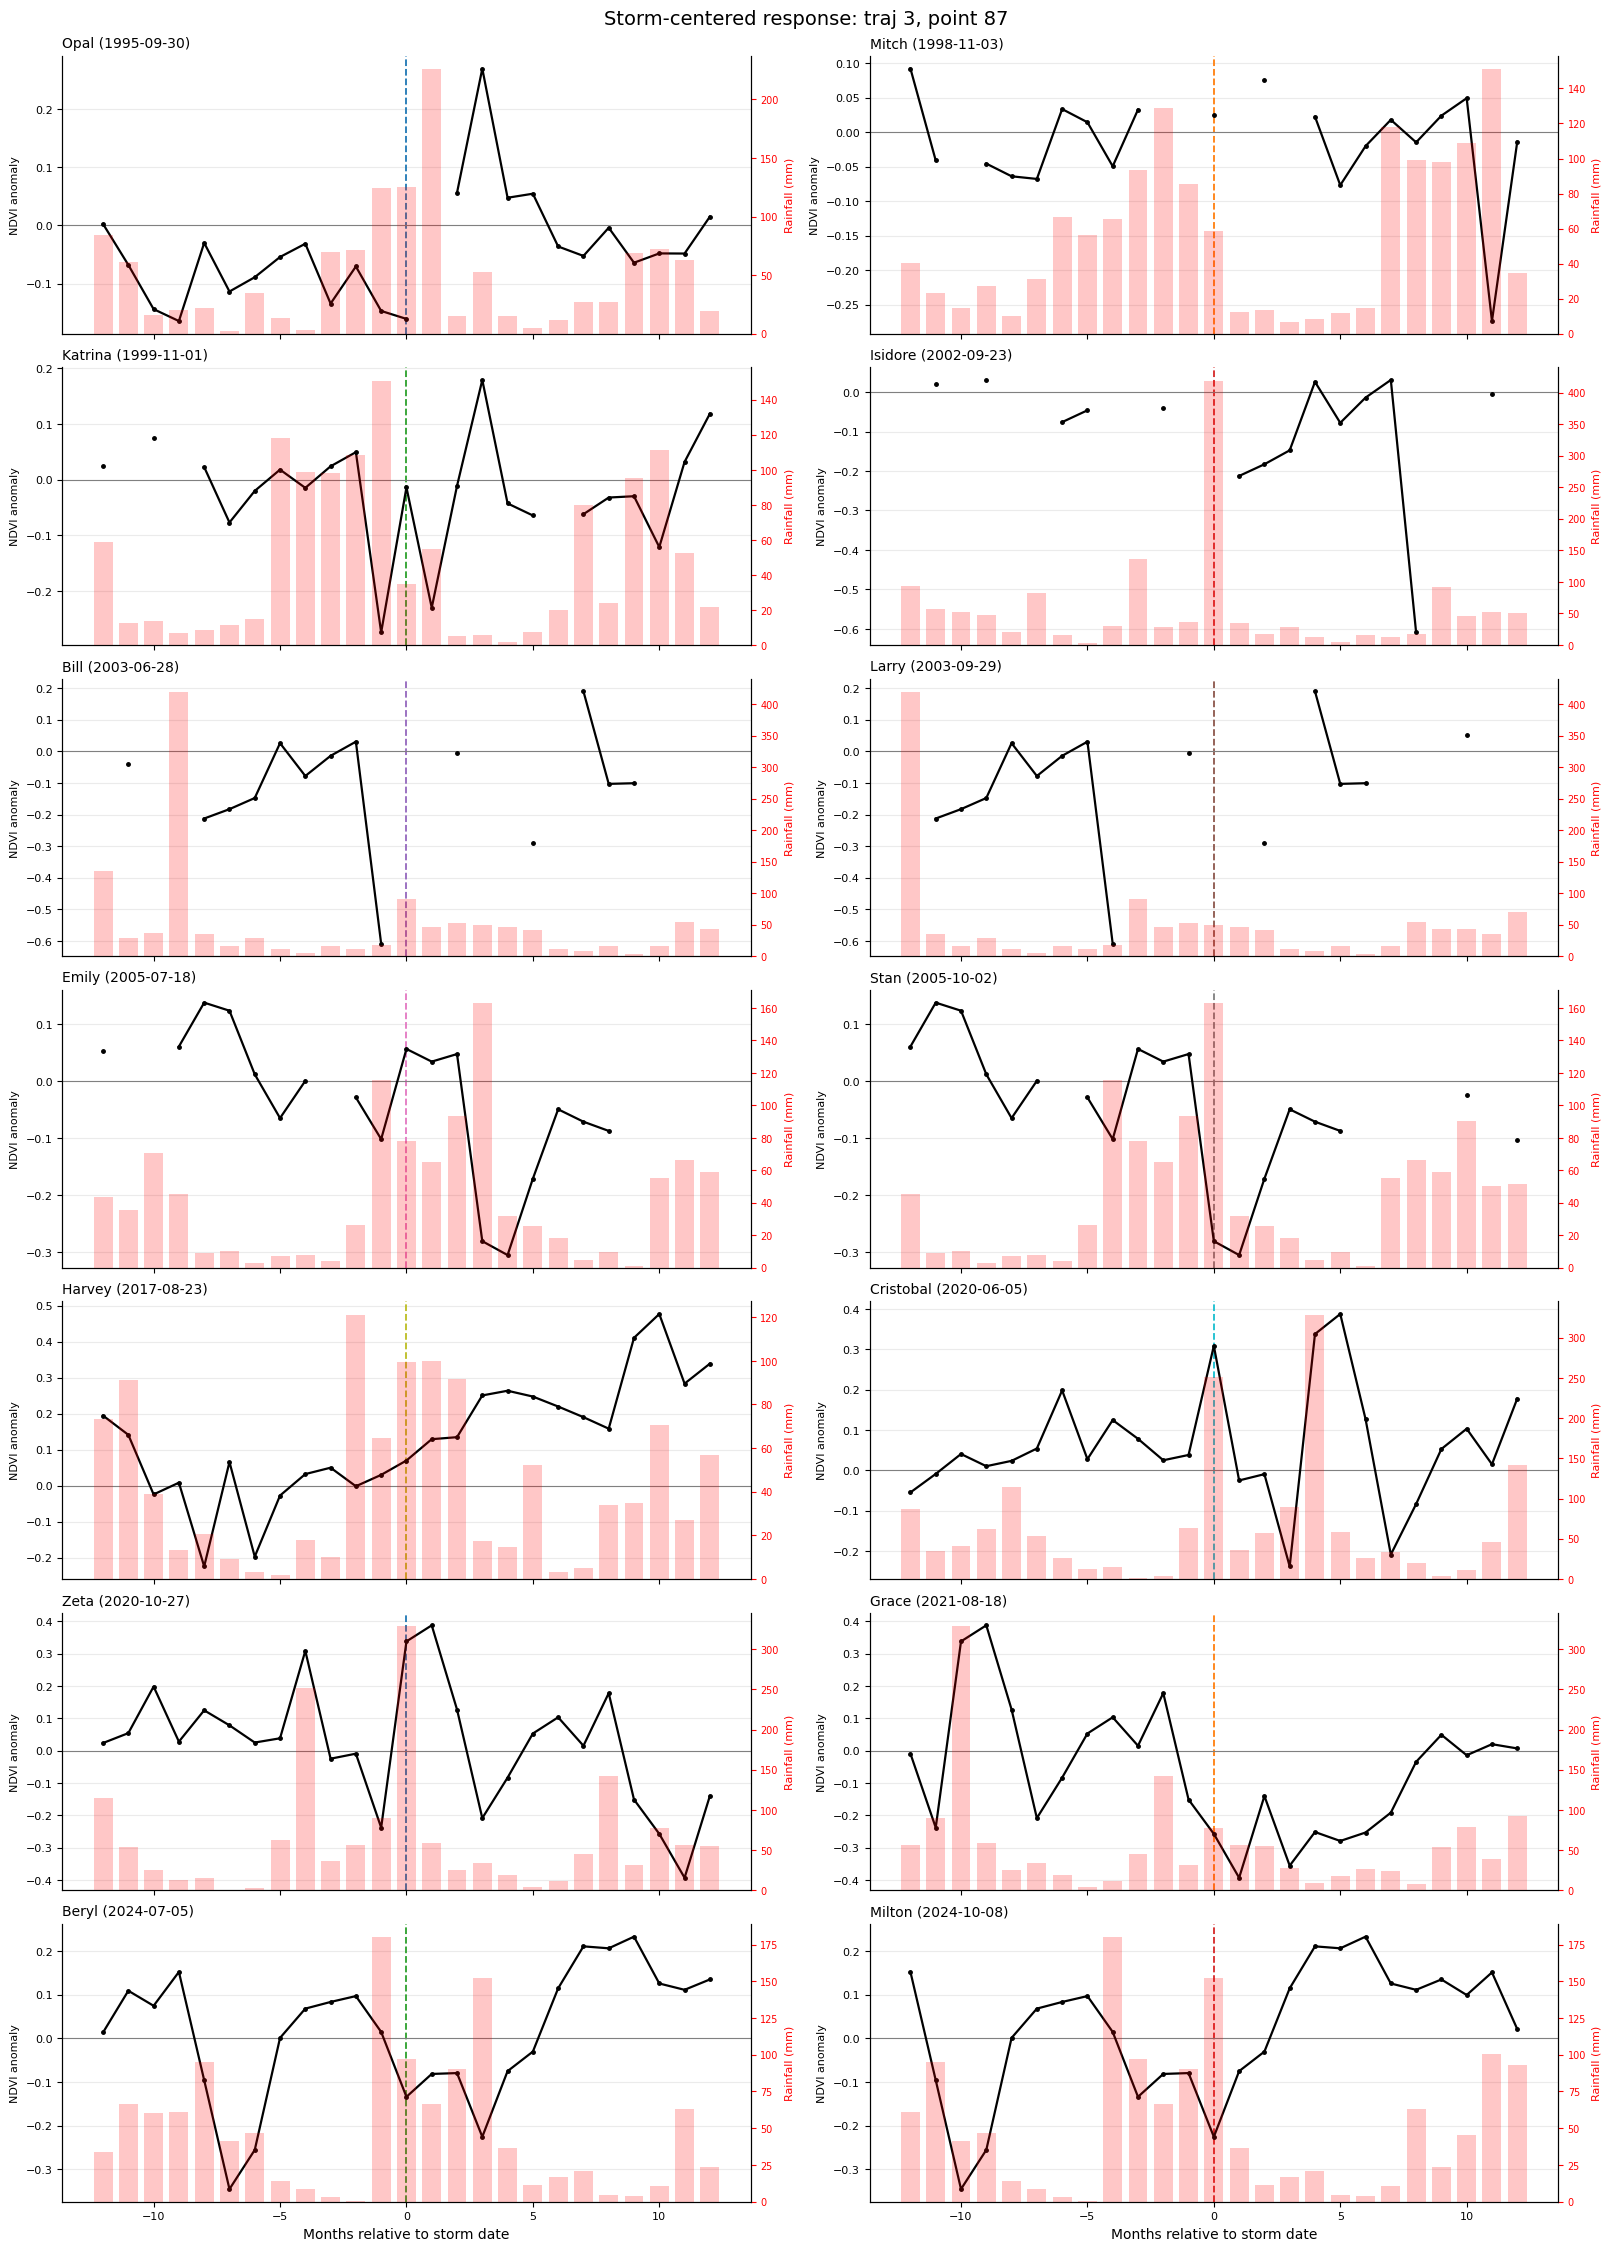

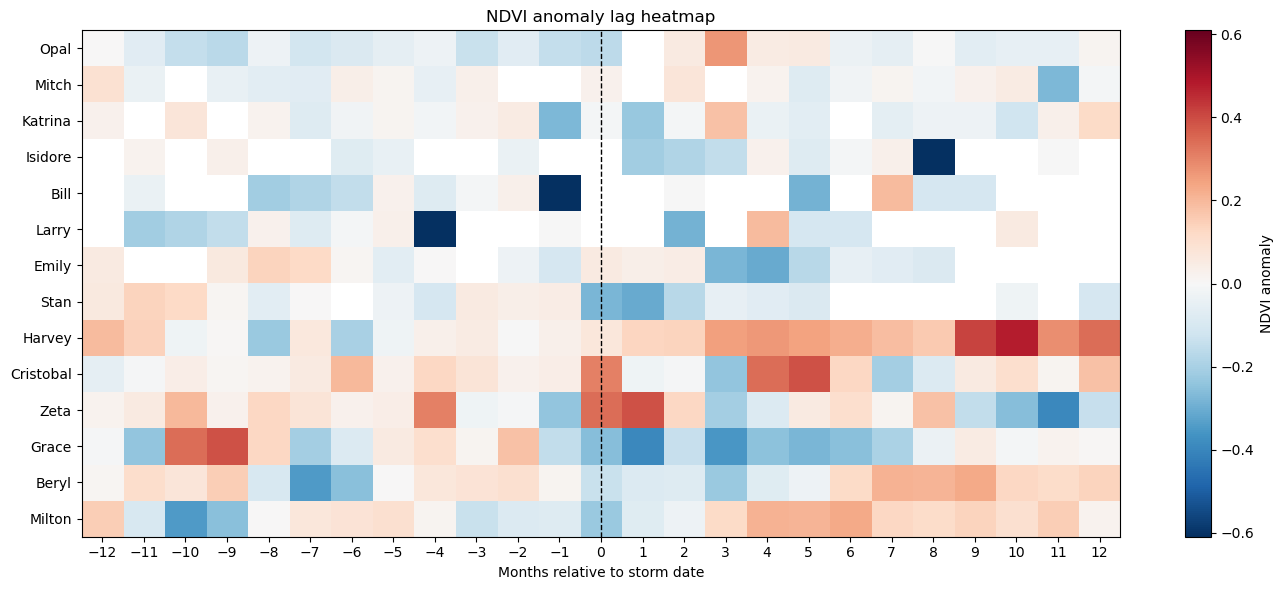

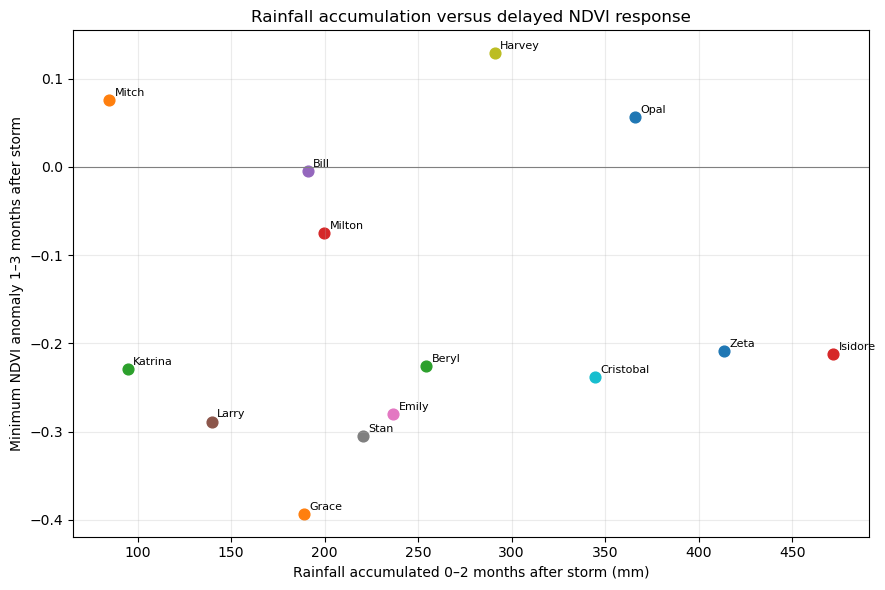

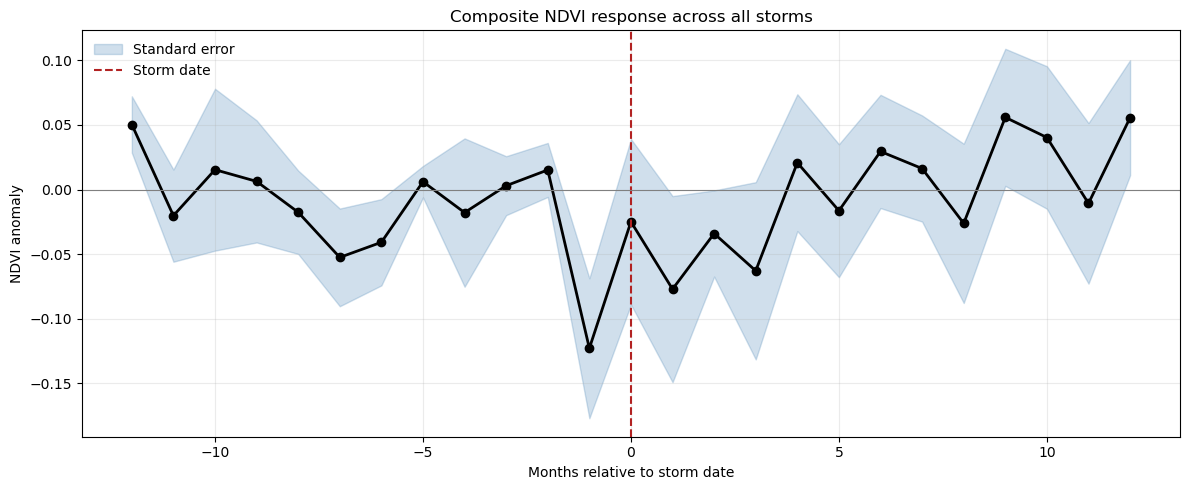

In [35]:
# Research plots: all-storm response, lag heatmap, rainfall response, and composite
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

NDVI_PATH = Path('../NDVI_data/Sisal_Landsat_monthly_max_NDVI_per_point.csv')
RAINFALL_PATH = Path('Sisal_ERA5Land_daily_all.csv')
TRAJ = 3
POINT_ID = None  # None selects one reproducible point; set an id to choose explicitly
STORMS = [
    ('Opal', '1995-09-30', '#1f77b4'),
    ('Mitch', '1998-11-03', '#ff7f0e'),
    ('Katrina', '1999-11-01', '#2ca02c'),
    ('Isidore', '2002-09-23', '#d62728'),
    ('Bill', '2003-06-28', '#9467bd'),
    ('Larry', '2003-09-29', '#8c564b'),
    ('Emily', '2005-07-18', '#e377c2'),
    ('Stan', '2005-10-02', '#7f7f7f'),
    ('Harvey', '2017-08-23', '#bcbd22'),
    ('Cristobal', '2020-06-05', '#17becf'),
    ('Zeta', '2020-10-27', '#1f77b4'),
    ('Grace', '2021-08-18', '#ff7f0e'),
    ('Beryl', '2024-07-05', '#2ca02c'),
    ('Milton', '2024-10-08', '#d62728'),
]
MONTHS_BEFORE = 12
MONTHS_AFTER = 12

ndvi_df = pd.read_csv(NDVI_PATH)
traj_points = ndvi_df.loc[ndvi_df['traj'].eq(TRAJ), 'point_id'].drop_duplicates()
if POINT_ID is None:
    POINT_ID = int(traj_points.sample(1, random_state=42).iloc[0])

ndvi = ndvi_df.loc[
    ndvi_df['traj'].eq(TRAJ) & ndvi_df['point_id'].eq(POINT_ID),
    ['year', 'month', 'ndvi_max']
].copy()
ndvi['date'] = pd.to_datetime(ndvi[['year', 'month']].assign(day=1))
ndvi = ndvi.set_index('date')['ndvi_max'].sort_index()

rain_df = pd.read_csv(RAINFALL_PATH, parse_dates=['date'])
rain = (rain_df.set_index('date')['precip_mm_c1']
        .resample('MS').sum(min_count=1)
        .rename('rainfall_mm'))

# Monthly NDVI climatology, used to calculate seasonal anomalies.
ndvi_clim = ndvi.groupby(ndvi.index.month).mean()
ndvi_anom = ndvi - ndvi_clim.reindex(ndvi.index.month).to_numpy()

relative_months = np.arange(-MONTHS_BEFORE, MONTHS_AFTER + 1)
storm_windows = {}
for name, date_text, color in STORMS:
    storm_date = pd.Timestamp(date_text)
    center = storm_date.to_period('M').to_timestamp()
    months = pd.date_range(
        center - pd.DateOffset(months=MONTHS_BEFORE),
        center + pd.DateOffset(months=MONTHS_AFTER),
        freq='MS'
    )
    storm_windows[name] = {
        'date': storm_date,
        'months': months,
        'ndvi': ndvi_anom.reindex(months).to_numpy(),
        'rain': rain.reindex(months).to_numpy(),
        'color': color,
    }

# 1. Storm-centered NDVI anomalies with rainfall bars in a two-column grid.
n_storms = len(STORMS)
ncols = 2
nrows = int(np.ceil(n_storms / ncols))
fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(16, 3.2 * nrows),
    sharex=True,
    constrained_layout=True,
)
axes = np.asarray(axes).ravel()
for ax, (name, date_text, color) in zip(axes, STORMS):
    result = storm_windows[name]
    ax_rain = ax.twinx()
    ax_rain.bar(
        relative_months, result['rain'], width=0.75,
        color='red', alpha=0.22, zorder=0,
    )
    ax.plot(
        relative_months, result['ndvi'],
        color='black', marker='o', ms=2.5, lw=1.6, zorder=3,
    )
    ax.axvline(0, color=color, ls='--', lw=1.3)
    ax.axhline(0, color='grey', lw=0.8)
    ax.set_title(f'{name} ({pd.Timestamp(date_text):%Y-%m-%d})', loc='left', fontsize=10)
    ax.set_ylabel('NDVI anomaly', fontsize=8)
    ax_rain.set_ylabel('Rainfall (mm)', color='red', fontsize=8)
    ax_rain.tick_params(axis='y', colors='red', labelsize=7)
    ax.tick_params(labelsize=8)
    ax.grid(axis='y', alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax_rain.spines['top'].set_visible(False)
for ax in axes[n_storms:]:
    ax.set_visible(False)
for ax in axes[-ncols:]:
    ax.set_xlabel('Months relative to storm date')
fig.suptitle(f'Storm-centered response: traj {TRAJ}, point {POINT_ID}', fontsize=14)

# 2. Lag heatmap of NDVI anomalies.
heatmap = np.array([storm_windows[name]['ndvi'] for name, _, _ in STORMS])
limit = np.nanmax(np.abs(heatmap))
fig_heat, ax_heat = plt.subplots(figsize=(14, 6))
im = ax_heat.imshow(
    heatmap, aspect='auto', cmap='RdBu_r', vmin=-limit, vmax=limit,
    extent=[-12.5, 12.5, n_storms - 0.5, -0.5]
)
ax_heat.set_yticks(range(n_storms))
ax_heat.set_yticklabels([name for name, _, _ in STORMS])
ax_heat.set_xticks(relative_months)
ax_heat.set_xlabel('Months relative to storm date')
ax_heat.set_title('NDVI anomaly lag heatmap')
ax_heat.axvline(0, color='black', ls='--', lw=1)
fig_heat.colorbar(im, ax=ax_heat, label='NDVI anomaly')
fig_heat.tight_layout()

# 3. Rainfall accumulation versus subsequent NDVI response.
scatter_rows = []
for name, _, _ in STORMS:
    result = storm_windows[name]
    rain_after = result['rain'][(relative_months >= 0) & (relative_months <= 2)]
    ndvi_after = result['ndvi'][(relative_months >= 1) & (relative_months <= 3)]
    scatter_rows.append({
        'storm': name,
        'rainfall_0_to_2_months': np.nansum(rain_after),
        'minimum_ndvi_anomaly_1_to_3_months': np.nanmin(ndvi_after),
    })
scatter = pd.DataFrame(scatter_rows)
fig_scatter, ax_scatter = plt.subplots(figsize=(9, 6))
for name, _, color in STORMS:
    row = scatter.loc[scatter['storm'].eq(name)].iloc[0]
    ax_scatter.scatter(
        row['rainfall_0_to_2_months'],
        row['minimum_ndvi_anomaly_1_to_3_months'],
        color=color, s=60, label=name,
    )
    ax_scatter.annotate(
        name,
        (row['rainfall_0_to_2_months'], row['minimum_ndvi_anomaly_1_to_3_months']),
        xytext=(4, 3), textcoords='offset points', fontsize=8,
    )
ax_scatter.axhline(0, color='grey', lw=0.8)
ax_scatter.set_xlabel('Rainfall accumulated 0–2 months after storm (mm)')
ax_scatter.set_ylabel('Minimum NDVI anomaly 1–3 months after storm')
ax_scatter.set_title('Rainfall accumulation versus delayed NDVI response')
ax_scatter.grid(alpha=0.25)
fig_scatter.tight_layout()

# 4. Composite storm response with mean and standard error.
composite_mean = np.nanmean(heatmap, axis=0)
composite_se = np.nanstd(heatmap, axis=0, ddof=1) / np.sqrt(np.sum(~np.isnan(heatmap), axis=0))
fig_composite, ax_composite = plt.subplots(figsize=(12, 5))
ax_composite.plot(relative_months, composite_mean, color='black', lw=2, marker='o')
ax_composite.fill_between(
    relative_months,
    composite_mean - composite_se,
    composite_mean + composite_se,
    color='steelblue', alpha=0.25, label='Standard error',
)
ax_composite.axvline(0, color='firebrick', ls='--', label='Storm date')
ax_composite.axhline(0, color='grey', lw=0.8)
ax_composite.set_xlabel('Months relative to storm date')
ax_composite.set_ylabel('NDVI anomaly')
ax_composite.set_title('Composite NDVI response across all storms')
ax_composite.legend(frameon=False)
ax_composite.grid(alpha=0.25)
fig_composite.tight_layout()

plt.show()


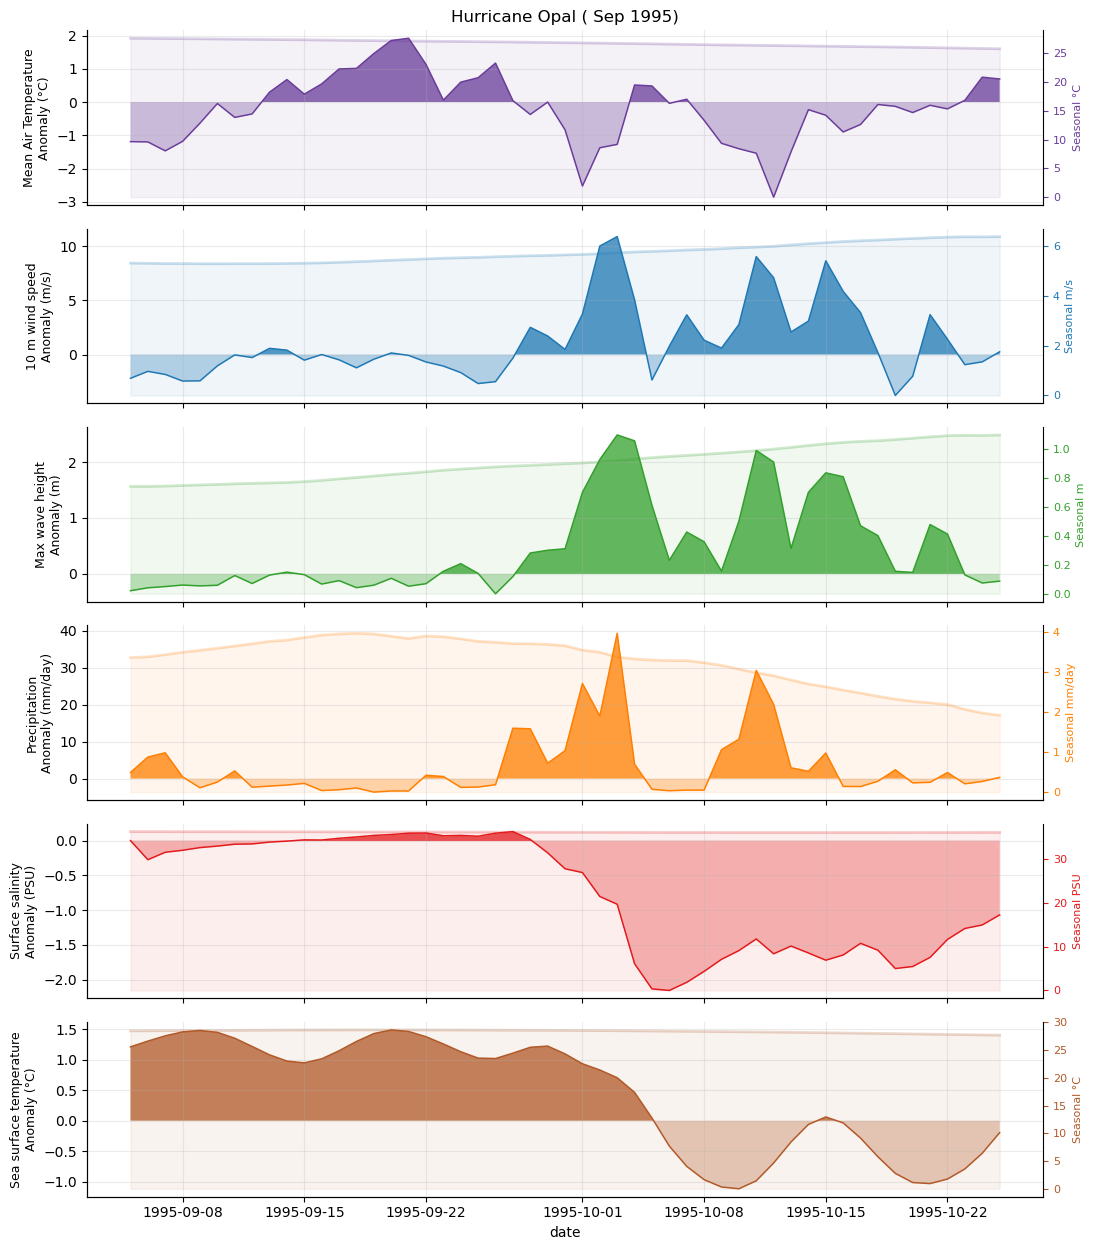

In [37]:
# Event anomaly panels with every variable's seasonal climatology in the background
import matplotlib.pyplot as plt

EVENT_NAME = 'Hurricane Opal'
EVENT_DATE = '1995-09-30'
DAYS_BEFORE = 25
DAYS_AFTER = 25

FILES = {
    'era5':     'Sisal_ERA5_daily_all.csv',
    'era5land': 'Sisal_ERA5Land_daily_all.csv',
    'hycom':    'Sisal_HYCOM_daily_all.csv',
}

PANELS = [
    ('era5land', 't2m_c_c1',              'Mean Air Temperature', '°C',    '#6a3d9a'),
    ('era5',     'wind_speed_ms',         '10 m wind speed',      'm/s',   '#1f78b4'),
    ('era5',     'hs_max_m',              'Max wave height',      'm',     '#33a02c'),
    ('era5land', 'precip_mm_c1',          'Precipitation',        'mm/day','#ff7f00'),
    ('hycom',    'salinity_surface_psu', 'Surface salinity',     'PSU',   '#e31a1c'),
    ('era5',     'sst_c',                 'Sea surface temperature', '°C', '#b15928'),
]

def load(path):
    df = pd.read_csv(path)
    date_col = 'date' if 'date' in df.columns else df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col])
    return df.groupby(date_col).mean(numeric_only=True).sort_index()

def doy365(idx):
    doy = idx.dayofyear.values.copy()
    doy[idx.is_leap_year & (doy > 59)] -= 1
    return doy

def anomaly(s, window=11, smooth=31):
    s = s.dropna()
    r = pd.Series(s.values, index=doy365(s.index))
    half = window // 2
    clim = {}
    for day in range(1, 366):
        window_days = [(day + offset - 1) % 365 + 1
                       for offset in range(-half, half + 1)]
        values = r[r.index.isin(window_days)].values
        clim[day] = np.nanmean(values) if values.size else np.nan
    clim = pd.Series(clim)
    clim = pd.concat([clim] * 3).rolling(
        smooth, center=True, min_periods=1
    ).mean().iloc[365:730]
    clim.index = range(1, 366)
    return s - clim.reindex(doy365(s.index)).values

def seasonal_cycle(s, smooth=31):
    s = s.dropna()
    by_doy = pd.Series(s.values, index=doy365(s.index)).groupby(level=0).mean()
    cycle = by_doy.reindex(range(1, 366))
    cycle = pd.concat([cycle] * 3).rolling(
        smooth, center=True, min_periods=1
    ).mean().iloc[365:730]
    cycle.index = range(1, 366)
    return cycle

# Load all event data and calculate one seasonal cycle per variable.
data = {source: load(path) for source, path in FILES.items()}
seasonal = {}
for source, column, label, unit, color in PANELS:
    seasonal[column] = seasonal_cycle(data[source][column])

# Event window.
t0 = pd.Timestamp(EVENT_DATE)
lo = t0 - pd.Timedelta(days=DAYS_BEFORE)
hi = t0 + pd.Timedelta(days=DAYS_AFTER)

fig, axes = plt.subplots(
    len(PANELS), 1,
    figsize=(11, 2.1 * len(PANELS)),
    sharex=True,
)
if len(PANELS) == 1:
    axes = [axes]

for ax, (src, column, label, unit, color) in zip(axes, PANELS):
    series_anomaly = anomaly(data[src][column])
    window_anomaly = series_anomaly.loc[lo:hi]
    clim_dates = window_anomaly.index
    clim_values = seasonal[column].reindex(doy365(clim_dates)).to_numpy()

    # Secondary axis keeps the absolute seasonal cycle separate from anomalies.
    ax_clim = ax.twinx()
    ax_clim.plot(
        clim_dates, clim_values,
        color=color, lw=2.0, alpha=0.22,
        label=f'Average seasonal {label.lower()}', zorder=0,
    )
    ax_clim.fill_between(
        clim_dates, 0, clim_values,
        color=color, alpha=0.07, zorder=0,
    )
    ax_clim.set_ylabel(f'Seasonal {unit}', color=color, fontsize=8)
    ax_clim.tick_params(axis='y', colors=color, labelsize=8)
    ax_clim.spines['top'].set_visible(False)
    ax.set_zorder(ax_clim.get_zorder() + 1)
    ax.patch.set_visible(False)

    # Foreground event anomaly, matching the original six-panel graph.
    ax.fill_between(
        window_anomaly.index, window_anomaly.values, 0,
        where=(window_anomaly.values >= 0), color=color,
        alpha=0.75, interpolate=True, linewidth=0,
    )
    ax.fill_between(
        window_anomaly.index, window_anomaly.values, 0,
        where=(window_anomaly.values < 0), color=color,
        alpha=0.30, interpolate=True, linewidth=0,
    )
    ax.plot(window_anomaly.index, window_anomaly.values, color=color, lw=1.1)
    ax.set_ylabel(f'{label}\nAnomaly ({unit})', fontsize=9)
    ax.grid(alpha=0.25)
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_title(f'{EVENT_NAME} ({t0: %b %Y})', fontsize=12)
axes[-1].set_xlabel('date')
fig.tight_layout()
plt.show()
